In [1]:
!pip install gymnasium
!pip install stable-baselines3[extra]
!pip install tensorboard
%load_ext tensorboard
!pip install torch --upgrade --force-reinstall

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 60.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 13.1 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalli

# **DQN agent with simple binary rewards for storage volume constraints with smaller time steps (threshold) each episode - Agent Based State Propagation - Variation # 1**

Streaming output truncated to the last 5000 lines.
| train/              |          |
|    learning_rate    | 0.001    |
|    loss             | 6.72     |
|    n_updates        | 560014   |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 120      |
|    ep_rew_mean      | 117      |
|    exploration_rate | 0.01     |
| time/               |          |
|    episodes         | 18672    |
|    fps              | 562      |
|    time_elapsed     | 3982     |
|    total_timesteps  | 2240640  |
| train/              |          |
|    learning_rate    | 0.001    |
|    loss             | 2.18     |
|    n_updates        | 560134   |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 120      |
|    ep_rew_mean      | 118      |
|    exploration_rate | 0.01     |
| time/               |          |
|    episodes         | 18676    |
|   

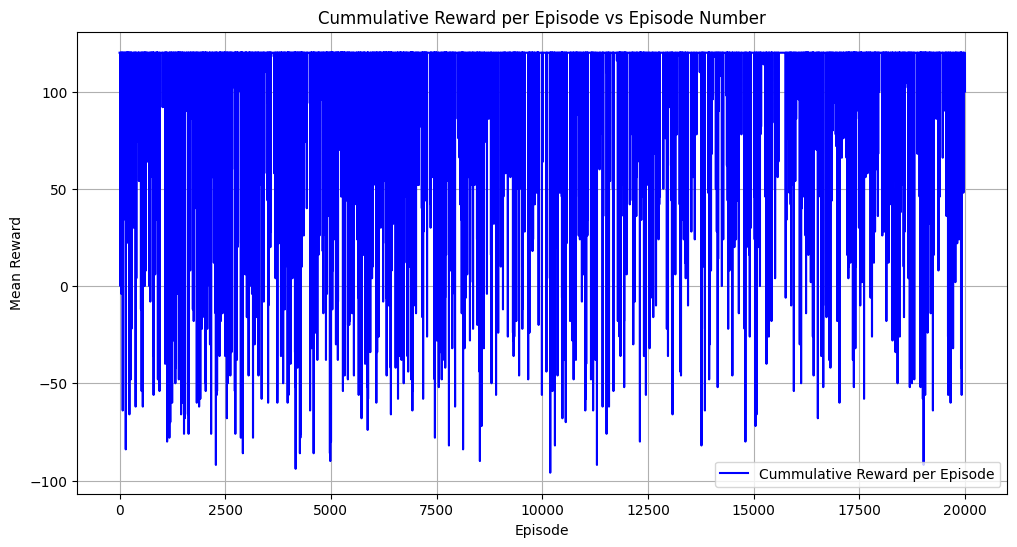

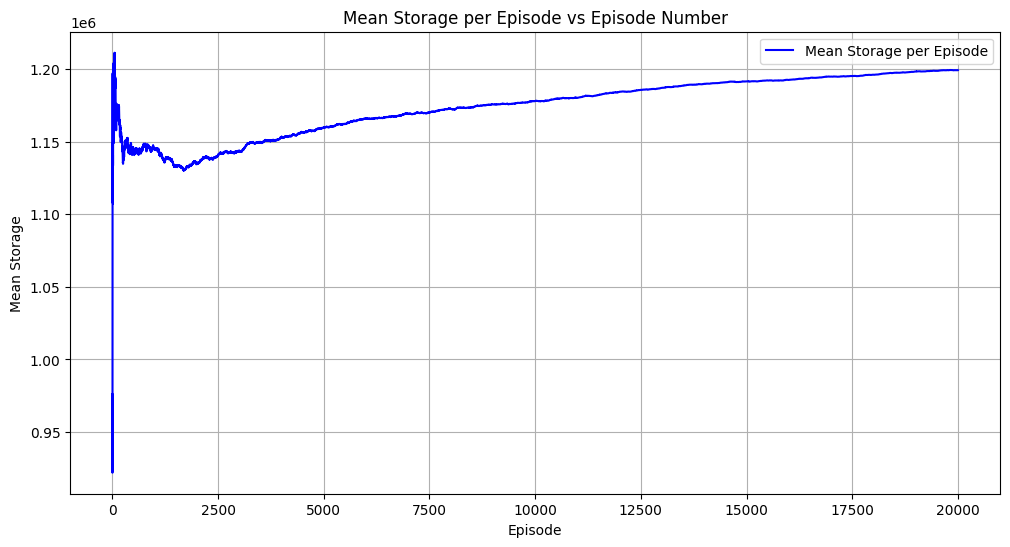

Training complete. Model and reward plot saved.


In [ ]:
# Import necessary libraries
import os
import numpy as np
import pandas as pd
import torch as th
import gymnasium
from gymnasium import Env
from gymnasium.spaces import Discrete, Box
from stable_baselines3 import DQN
from stable_baselines3.common.callbacks import BaseCallback
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Define storage and release limits (scaled values will be calculated later)
min_storage_af = 500000
max_storage_af = 1800000
initial_storage_af = 500000
target_storage_af = (min_storage_af + max_storage_af) / 2
release_cfs_discrete = [500, 1000, 1500, 2000, 2500, 3000, 4000]  # More discrete release values
release_af = [r * 1.98211 for r in release_cfs_discrete]  # Convert cfs to acre-feet

# Load and preprocess data
data = pd.read_csv('/content/Clipped_NAVAJORESERVOIR08-18-2024T16.48.23.csv')
storage = data['Storage (af)'].values
evaporation = data['Evaporation (af)'].values
inflow_cfs = data['Inflow** (cfs)'].values
release_cfs = data['Total Release (cfs)'].values
dataset = np.column_stack((storage, evaporation, inflow_cfs * 1.98211, release_cfs * 1.98211))

# Define the custom Reservoir environment
class ReservoirEnv(Env):
    def __init__(self, dataset, release_af, min_storage_af,max_storage_af, episode_length):
        super(ReservoirEnv, self).__init__()
        self.data = dataset
        self.episode_length = episode_length
        self.release_af = release_af
        self.min_storage_af = min_storage_af
        self.max_storage_af = max_storage_af
        self.current_step = 0
        self.episode_step_count = 0
        self.reward_history=[]
        self.episode_reward=[]
        self.storage_history=[]
        self.mean_storage_history = []


        # Define action space and observation space
        self.action_space = Discrete(len(self.release_af))  # Actions: scaled release values
        self.observation_space = Box(low=0, high=1, shape=(3,), dtype=np.float32)

    def reset(self, seed=None):
        self.current_step = np.random.randint(0, len(self.data) - self.episode_length)
        self.episode_step_count = 0
        self.reward_history.clear()

        # Set the storage to the value corresponding to the start of the episode
        self.current_storage = self.data[self.current_step, 0]
        return self._get_observation(), {}

    def _get_observation(self):
        return np.array([self.current_storage, self.data[self.current_step, 1], self.data[self.current_step, 2]])

    def step(self, action):
        # Mapping action index to scaled release value
        release_af_value = self.release_af[action]
        inflow_af = self.data[self.current_step, 2]
        evaporation_af = self.data[self.current_step, 1]

        # Updating storage with inflow, evaporation, and release (all in scaled values)
        self.current_storage += inflow_af - evaporation_af - release_af_value
        # print(f"Step {self.current_step}: Actual Storage: {self.data[self.current_step, 0]}, Current Storage: {self.current_storage}, Actual Release: {self.data[self.current_step, 3]}, Predicted Release: {release_af_value}")

        # Reward calculation (scaled storage range: 0 to 1)
        if self.min_storage_af<= self.current_storage <= self.max_storage_af:
            reward = 1 # Positive reward for staying within bounds
            # reward = 1- (abs(self.current_storage - target_storage_af) / target_storage_af)  # Positive reward for staying within bounds
        else:
            reward = -1  # Negative reward for going out of bounds

        self.reward_history.append(reward)
        self.storage_history.append(self.current_storage)
        self.current_step += 1
        self.episode_step_count += 1
        done = self.current_step >= len(self.data) or (self.episode_step_count % self.episode_length == 0)

        # Recording mean rewards after each episode
        if done:
            cum_reward = sum(self.reward_history)
            self.episode_reward.append(cum_reward)
            self.mean_storage_history.append(np.mean(self.storage_history))

        observation = self._get_observation() if not done else np.zeros(3)
        return observation, reward, done, False, {}

    def render(self, mode='human', close=False):
        pass

# Set up environment
episode_length = 120
env = ReservoirEnv(dataset, release_af, min_storage_af,max_storage_af, episode_length)

# Initialize DQN model
model = DQN(
    "MlpPolicy",
    env,
    verbose=1,
    learning_rate=1e-3,
    batch_size=32,
    train_freq=4,
    buffer_size=100000,
    exploration_fraction=0.3,
    exploration_final_eps=0.01,
    target_update_interval=1000,
)

# Training the model
n_episodes = 20000
total_timesteps = n_episodes * episode_length
model.learn(total_timesteps=total_timesteps)

# Save the model
model.save("dqn_reservoir_agent")

# Plot mean rewards per episode
plt.figure(figsize=(12, 6))
plt.plot(env.episode_reward, label="Cummulative Reward per Episode", color="blue")
plt.xlabel("Episode")
plt.ylabel("Mean Reward")
plt.title("Cummulative Reward per Episode vs Episode Number")
plt.grid()
plt.legend()
plt.savefig("cummulative_rewards_per_episode.png")
plt.show()

# Plot mean storage per episode
plt.figure(figsize=(12, 6))
plt.plot(env.mean_storage_history, label="Mean Storage per Episode", color="blue")
plt.xlabel("Episode")
plt.ylabel("Mean Storage")
plt.title("Mean Storage per Episode vs Episode Number")
plt.grid()
plt.legend()
plt.savefig("mean_storage_per_episode.png")
plt.show()

print("Training complete. Model and reward plot saved.")

506159.0
Prediction completed and saved to CSV files.


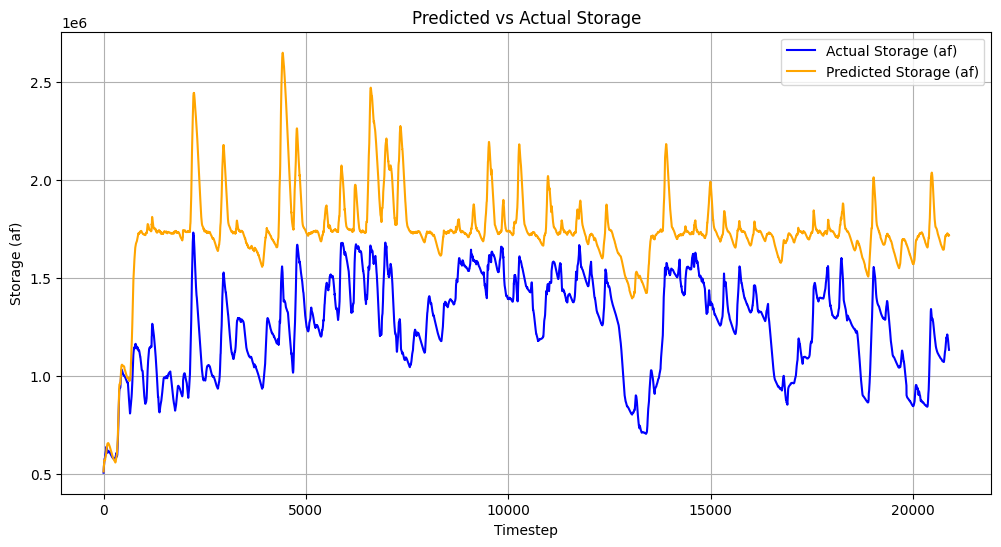

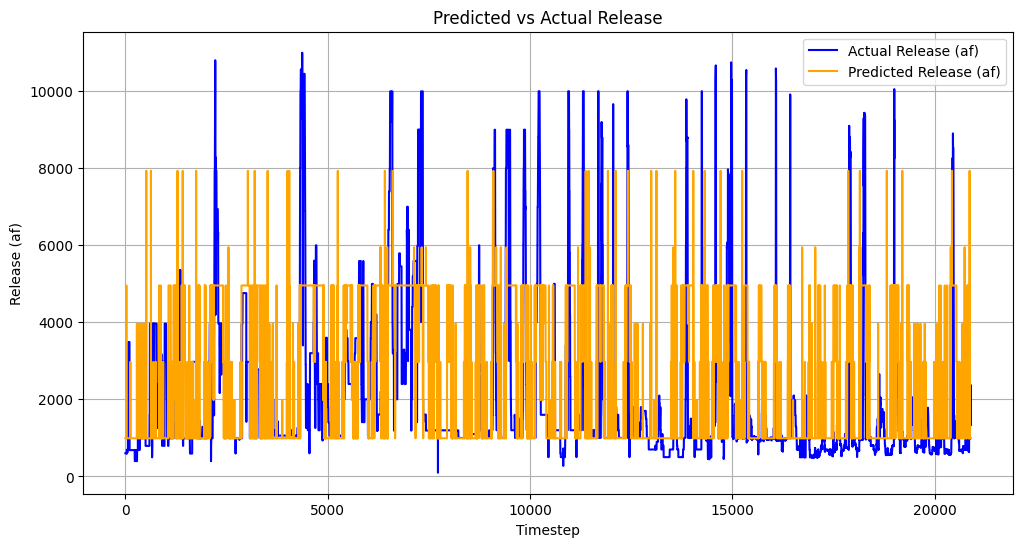

In [ ]:
# Load the trained DQN agent
model = DQN.load("dqn_reservoir_agent")

# Set up variables for predictions
predicted_storage = []
actual_storage = []
predicted_release = []
actual_release = []

# Initialize current storage
current_storage = dataset[0,0]
print(current_storage)

# Perform predictions
for i in range(len(dataset)):
    # Get the observation from the dataset (without scaling)
    observation = np.array([current_storage, dataset[i, 1], dataset[i, 2]])
    # Predict the action using the trained agent
    action, _ = model.predict(observation)

    # Map the action to the corresponding release value in acre-feet
    predicted_release_af = release_af[action]

    # Extract inflow and evaporation directly from the dataset (unscaled)
    inflow_af = dataset[i, 2]
    evaporation_af = dataset[i, 1]

    # Update the current storage using the predicted release, inflow, and evaporation
    current_storage += inflow_af - evaporation_af - predicted_release_af

    # Store results for analysis
    predicted_storage.append(current_storage)
    predicted_release.append(predicted_release_af)
    actual_storage.append(dataset[i, 0])  # Actual storage from the dataset
    actual_release.append(dataset[i, 3])  # Actual release from the dataset
    # print(f"Step {i}: Observation: {observation}, Predicted Release: {predicted_release_af}, Current Storage: {current_storage}")


# Save results to CSV files
predicted_vs_actual_storage = pd.DataFrame({
    "Predicted Storage (af)": predicted_storage,
    "Actual Storage (af)": actual_storage
})
predicted_vs_actual_release = pd.DataFrame({
    "Predicted Release (af)": predicted_release,
    "Actual Release (af)": actual_release
})

# Save the results to CSV files
predicted_vs_actual_storage.to_csv("predicted_vs_actual_storage_complete_data.csv", index=False)
predicted_vs_actual_release.to_csv("predicted_vs_actual_release_complete_data.csv", index=False)
pd.DataFrame(dataset).to_csv("complete_dataset.csv", index=False)

print("Prediction completed and saved to CSV files.")

# Plot Predicted vs Actual Storage
plt.figure(figsize=(12, 6))
plt.plot(actual_storage, label="Actual Storage (af)", color="blue")
plt.plot(predicted_storage, label="Predicted Storage (af)", color="orange")
plt.xlabel("Timestep")
plt.ylabel("Storage (af)")
plt.title("Predicted vs Actual Storage")
plt.legend()
plt.grid()
plt.show()

# Plot Predicted vs Actual Release
plt.figure(figsize=(12, 6))
plt.plot(actual_release, label="Actual Release (af)", color="blue")
plt.plot(predicted_release, label="Predicted Release (af)", color="orange")
plt.xlabel("Timestep")
plt.ylabel("Release (af)")
plt.title("Predicted vs Actual Release")
plt.legend()
plt.grid()
plt.show()

# **DQN agent with simple binary rewards for storage volume constraints with smaller time steps (threshold) each episode - Agent Based State Propagation - Variation # 2**

Streaming output truncated to the last 5000 lines.
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 1.69     |
|    n_updates        | 560014   |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 120      |
|    ep_rew_mean      | 118      |
|    exploration_rate | 0.01     |
| time/               |          |
|    episodes         | 18672    |
|    fps              | 515      |
|    time_elapsed     | 4345     |
|    total_timesteps  | 2240640  |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 2.26     |
|    n_updates        | 560134   |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 120      |
|    ep_rew_mean      | 118      |
|    exploration_rate | 0.01     |
| time/               |          |
|    episodes         | 18676    |
|   

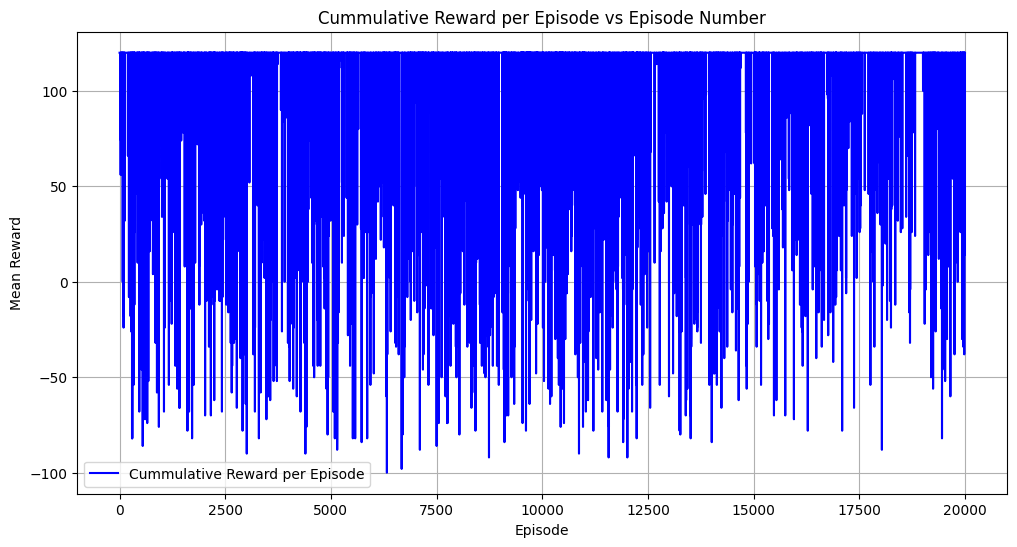

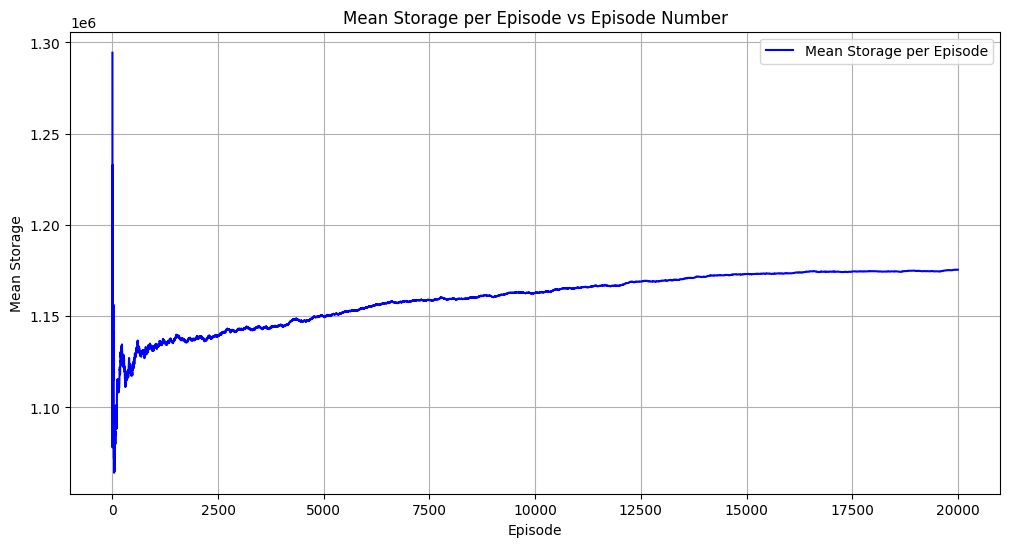

Training complete. Model and reward plot saved.


In [ ]:
# Import necessary libraries
import os
import numpy as np
import pandas as pd
import torch as th
import gymnasium
from gymnasium import Env
from gymnasium.spaces import Discrete, Box
from stable_baselines3 import DQN
from stable_baselines3.common.callbacks import BaseCallback
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Define storage and release limits (scaled values will be calculated later)
min_storage_af = 500000
max_storage_af = 1800000
initial_storage_af = 500000
target_storage_af = (min_storage_af + max_storage_af) / 2
release_cfs_discrete = [500, 1000, 1500, 2000, 2500, 3000, 3500, 4000]  # More discrete release values
release_af = [r * 1.98211 for r in release_cfs_discrete]  # Convert cfs to acre-feet

# Load and preprocess data
data = pd.read_csv('/content/Clipped_NAVAJORESERVOIR08-18-2024T16.48.23.csv')
storage = data['Storage (af)'].values
evaporation = data['Evaporation (af)'].values
inflow_cfs = data['Inflow** (cfs)'].values
release_cfs = data['Total Release (cfs)'].values
dataset = np.column_stack((storage, evaporation, inflow_cfs * 1.98211, release_cfs * 1.98211))

# Define the custom Reservoir environment
class ReservoirEnv(Env):
    def __init__(self, dataset, release_af, min_storage_af,max_storage_af, episode_length):
        super(ReservoirEnv, self).__init__()
        self.data = dataset
        self.episode_length = episode_length
        self.release_af = release_af
        self.min_storage_af = min_storage_af
        self.max_storage_af = max_storage_af
        self.current_step = 0
        self.episode_step_count = 0
        self.reward_history=[]
        self.episode_reward=[]
        self.storage_history=[]
        self.mean_storage_history = []


        # Define action space and observation space
        self.action_space = Discrete(len(self.release_af))  # Actions: scaled release values
        self.observation_space = Box(low=0, high=1, shape=(3,), dtype=np.float32)

    def reset(self, seed=None):
        self.current_step = np.random.randint(0, len(self.data) - self.episode_length)
        self.episode_step_count = 0
        self.reward_history.clear()

        # Set the storage to the value corresponding to the start of the episode
        self.current_storage = self.data[self.current_step, 0]
        return self._get_observation(), {}

    def _get_observation(self):
        return np.array([self.current_storage, self.data[self.current_step, 1], self.data[self.current_step, 2]])

    def step(self, action):
        # Mapping action index to scaled release value
        release_af_value = self.release_af[action]
        inflow_af = self.data[self.current_step, 2]
        evaporation_af = self.data[self.current_step, 1]

        # Updating storage with inflow, evaporation, and release (all in scaled values)
        self.current_storage += inflow_af - evaporation_af - release_af_value
        # print(f"Step {self.current_step}: Actual Storage: {self.data[self.current_step, 0]}, Current Storage: {self.current_storage}, Actual Release: {self.data[self.current_step, 3]}, Predicted Release: {release_af_value}")

        # Reward calculation (scaled storage range: 0 to 1)
        if self.min_storage_af<= self.current_storage <= self.max_storage_af:
            reward = 1 # Positive reward for staying within bounds
            # reward = 1- (abs(self.current_storage - target_storage_af) / target_storage_af)  # Positive reward for staying within bounds
        else:
            reward = -1  # Negative reward for going out of bounds

        self.reward_history.append(reward)
        self.storage_history.append(self.current_storage)
        self.current_step += 1
        self.episode_step_count += 1
        done = self.current_step >= len(self.data) or (self.episode_step_count % self.episode_length == 0)

        # Recording mean rewards after each episode
        if done:
            cum_reward = sum(self.reward_history)
            self.episode_reward.append(cum_reward)
            self.mean_storage_history.append(np.mean(self.storage_history))

        observation = self._get_observation() if not done else np.zeros(3)
        return observation, reward, done, False, {}

    def render(self, mode='human', close=False):
        pass

# Set up environment
episode_length = 120
env = ReservoirEnv(dataset, release_af, min_storage_af,max_storage_af, episode_length)

# Initialize DQN model
model = DQN(
    "MlpPolicy",
    env,
    verbose=1,
    learning_rate=1e-4,
    batch_size=32,
    train_freq=4,
    buffer_size=100000,
    exploration_fraction=0.3,
    exploration_final_eps=0.01,
    target_update_interval=1000,
)

# Training the model
n_episodes = 20000
total_timesteps = n_episodes * episode_length
model.learn(total_timesteps=total_timesteps)

# Save the model
model.save("dqn_reservoir_agent")

# Plot mean rewards per episode
plt.figure(figsize=(12, 6))
plt.plot(env.episode_reward, label="Cummulative Reward per Episode", color="blue")
plt.xlabel("Episode")
plt.ylabel("Mean Reward")
plt.title("Cummulative Reward per Episode vs Episode Number")
plt.grid()
plt.legend()
plt.savefig("cummulative_rewards_per_episode.png")
plt.show()

# Plot mean storage per episode
plt.figure(figsize=(12, 6))
plt.plot(env.mean_storage_history, label="Mean Storage per Episode", color="blue")
plt.xlabel("Episode")
plt.ylabel("Mean Storage")
plt.title("Mean Storage per Episode vs Episode Number")
plt.grid()
plt.legend()
plt.savefig("mean_storage_per_episode.png")
plt.show()

pd.DataFrame(env.episode_reward).to_csv("cummulative_reward_per_episode.csv", index=False)
print("Training complete. Model and reward plot saved.")

506159.0
Prediction completed and saved to CSV files.


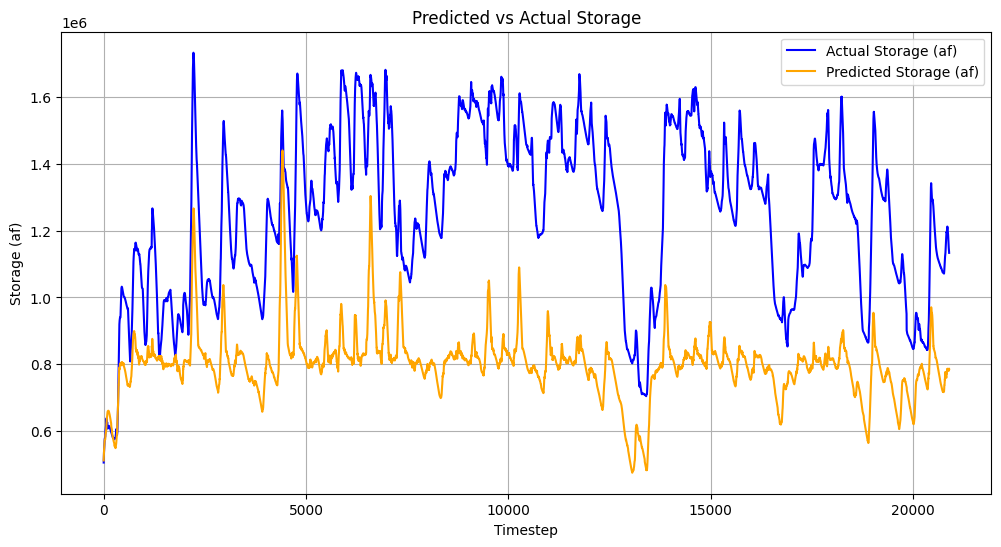

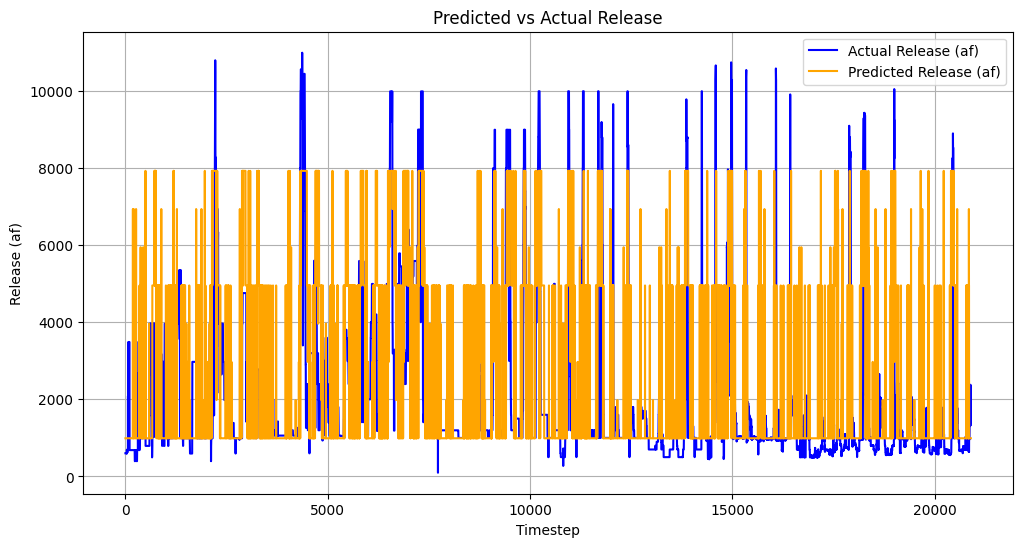

In [ ]:
# Load the trained DQN agent
model = DQN.load("dqn_reservoir_agent")

# Set up variables for predictions
predicted_storage = []
actual_storage = []
predicted_release = []
actual_release = []

# Initialize current storage
current_storage = dataset[0,0]
print(current_storage)

# Perform predictions
for i in range(len(dataset)):
    # Get the observation from the dataset (without scaling)
    observation = np.array([current_storage, dataset[i, 1], dataset[i, 2]])
    # Predict the action using the trained agent
    action, _ = model.predict(observation)

    # Map the action to the corresponding release value in acre-feet
    predicted_release_af = release_af[action]

    # Extract inflow and evaporation directly from the dataset (unscaled)
    inflow_af = dataset[i, 2]
    evaporation_af = dataset[i, 1]

    # Update the current storage using the predicted release, inflow, and evaporation
    current_storage += inflow_af - evaporation_af - predicted_release_af

    # Store results for analysis
    predicted_storage.append(current_storage)
    predicted_release.append(predicted_release_af)
    actual_storage.append(dataset[i, 0])  # Actual storage from the dataset
    actual_release.append(dataset[i, 3])  # Actual release from the dataset
    # print(f"Step {i}: Observation: {observation}, Predicted Release: {predicted_release_af}, Current Storage: {current_storage}")


# Save results to CSV files
predicted_vs_actual_storage = pd.DataFrame({
    "Predicted Storage (af)": predicted_storage,
    "Actual Storage (af)": actual_storage
})
predicted_vs_actual_release = pd.DataFrame({
    "Predicted Release (af)": predicted_release,
    "Actual Release (af)": actual_release
})

# Save the results to CSV files
predicted_vs_actual_storage.to_csv("predicted_vs_actual_storage_complete_data.csv", index=False)
predicted_vs_actual_release.to_csv("predicted_vs_actual_release_complete_data.csv", index=False)
pd.DataFrame(dataset).to_csv("complete_dataset.csv", index=False)

print("Prediction completed and saved to CSV files.")

# Plot Predicted vs Actual Storage
plt.figure(figsize=(12, 6))
plt.plot(actual_storage, label="Actual Storage (af)", color="blue")
plt.plot(predicted_storage, label="Predicted Storage (af)", color="orange")
plt.xlabel("Timestep")
plt.ylabel("Storage (af)")
plt.title("Predicted vs Actual Storage")
plt.legend()
plt.grid()
plt.show()

# Plot Predicted vs Actual Release
plt.figure(figsize=(12, 6))
plt.plot(actual_release, label="Actual Release (af)", color="blue")
plt.plot(predicted_release, label="Predicted Release (af)", color="orange")
plt.xlabel("Timestep")
plt.ylabel("Release (af)")
plt.title("Predicted vs Actual Release")
plt.legend()
plt.grid()
plt.show()

# **TD3 agent with simple binary rewards for storage volume constraints with smaller time steps (threshold) each episode - Agent Based State Propagation**

/usr/local/lib/python3.11/dist-packages/gymnasium/spaces/box.py:235: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/usr/local/lib/python3.11/dist-packages/gymnasium/spaces/box.py:305: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


Streaming output truncated to the last 5000 lines.
|    actor_loss      | -22.2    |
|    critic_loss     | 0.961    |
|    learning_rate   | 0.0003   |
|    n_updates       | 260014   |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 120      |
|    ep_rew_mean     | 107      |
| time/              |          |
|    episodes        | 8672     |
|    fps             | 167      |
|    time_elapsed    | 6216     |
|    total_timesteps | 1040640  |
| train/             |          |
|    actor_loss      | -22.3    |
|    critic_loss     | 1.19     |
|    learning_rate   | 0.0003   |
|    n_updates       | 260134   |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 120      |
|    ep_rew_mean     | 109      |
| time/              |          |
|    episodes        | 8676     |
|    fps             | 167      |
|    time_elapsed    | 6218    

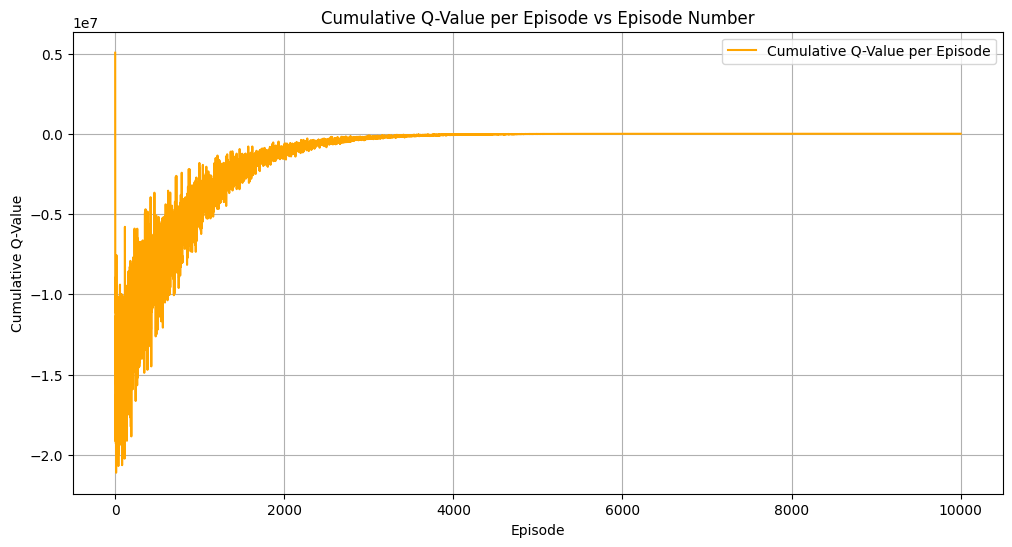

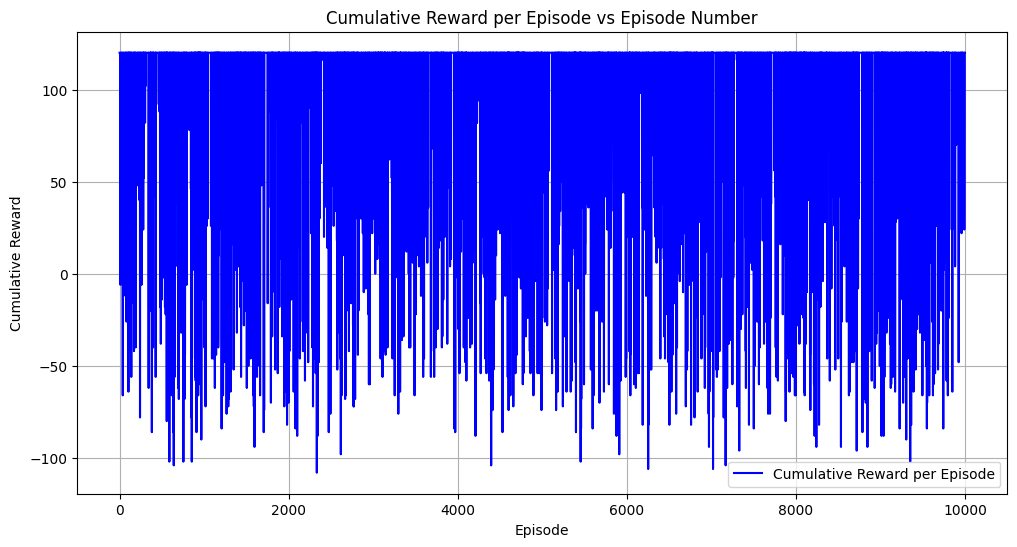

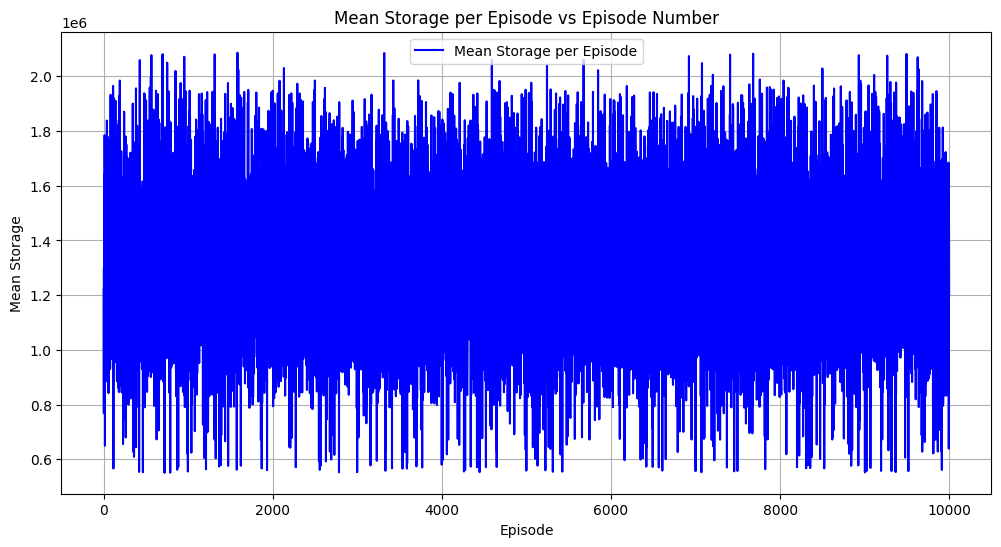

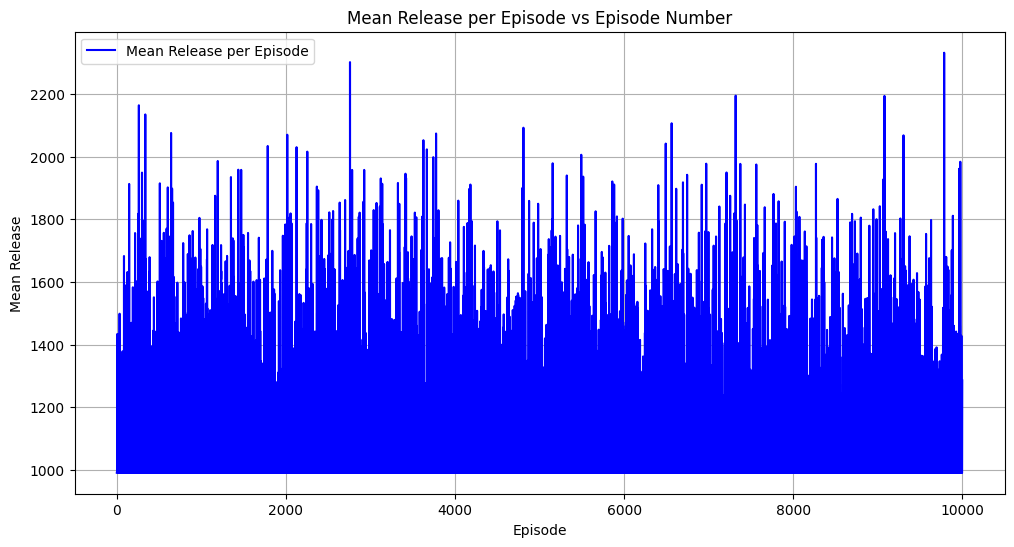

Training complete. Model, Q values, release, and reward plots saved.


In [ ]:
# Import necessary libraries
import os
import numpy as np
import pandas as pd
import torch as th
import gymnasium
from gymnasium import Env
from gymnasium.spaces import Box
from stable_baselines3 import TD3
from stable_baselines3.common.noise import NormalActionNoise
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Define storage and release limits
min_storage_af = 500000
max_storage_af = 1800000
initial_storage_af = 500000
target_storage_af = (min_storage_af + max_storage_af) / 2
min_release_af = 500 * 1.98211  # Minimum release in acre-feet
max_release_af = 4000 * 1.98211  # Maximum release in acre-feet

# Load and preprocess data
data = pd.read_csv('/content/Clipped_NAVAJORESERVOIR08-18-2024T16.48.23.csv')
storage = data['Storage (af)'].values
evaporation = data['Evaporation (af)'].values
inflow_cfs = data['Inflow** (cfs)'].values
release_cfs = data['Total Release (cfs)'].values
dataset = np.column_stack((storage, evaporation, inflow_cfs * 1.98211, release_cfs * 1.98211))

# Define the custom Reservoir environment
class ReservoirEnv(Env):
    def __init__(self, dataset, min_storage_af, max_storage_af, min_release_af, max_release_af, episode_length, td3_model):
        super(ReservoirEnv, self).__init__()
        self.data = dataset
        self.episode_length = episode_length
        self.min_storage_af = min_storage_af
        self.max_storage_af = max_storage_af
        self.min_release_af = min_release_af
        self.max_release_af = max_release_af
        self.td3_model = td3_model  # To compute Q-values
        self.current_step = 0
        self.episode_step_count = 0
        self.reward_history = []
        self.episode_reward = []
        self.storage_history = []
        self.mean_storage_history = []
        self.q_values = []  # To collect Q-values for each step
        self.cumulative_q_values = []  # To store cumulative Q-values per episode
        self.release_history=[]
        self.mean_release_history=[]


        # Define action space and observation space
        self.action_space = Box(low=-1, high=1, shape=(1,), dtype=np.float32)
        self.observation_space = Box(low=np.array([self.min_storage_af, np.min(self.data[:, 1]), np.min(self.data[:, 2])]),
                                     high=np.array([self.max_storage_af, np.max(self.data[:, 1]), np.max(self.data[:, 2])]),
                                     dtype=np.float32)

    def reset(self, seed=None):
        self.current_step = np.random.randint(0, len(self.data) - self.episode_length)
        self.episode_step_count = 0
        self.reward_history.clear()
        self.q_values.clear()  # Reset Q-value history
        self.storage_history.clear()
        self.release_history.clear()
        self.current_storage = self.data[self.current_step, 0]
        return self._get_observation(), {}

    def _get_observation(self):
        return np.array([self.current_storage, self.data[self.current_step, 1], self.data[self.current_step, 2]])

    def step(self, action):
        # normalized_release = (action[0] + 1) / 2  # Convert from [-1, 1] to [0, 1]
        normalized_release = np.clip((action[0] + 1) / 2, 0, 1)
        release_af_value = self.min_release_af + normalized_release * (self.max_release_af - self.min_release_af)

        inflow_af = self.data[self.current_step, 2]
        evaporation_af = self.data[self.current_step, 1]
        self.current_storage += inflow_af - evaporation_af - release_af_value

        if self.min_storage_af <= self.current_storage <= self.max_storage_af:
            reward = 1
        else:
            reward = -1

        # Compute Q-value
        obs_tensor = th.tensor(self._get_observation(), dtype=th.float32).unsqueeze(0).to(self.td3_model.device)
        action_tensor = th.tensor(action, dtype=th.float32).unsqueeze(0).to(self.td3_model.device)
        # with th.no_grad():
        #     q_value = self.td3_model.critic_target(obs_tensor, action_tensor)[0].mean().item()
        with th.no_grad():
          q_value = self.td3_model.critic(obs_tensor, action_tensor)[0].mean().item()
        self.q_values.append(q_value)

        self.reward_history.append(reward)
        self.storage_history.append(self.current_storage)
        self.current_step += 1
        self.episode_step_count += 1
        done = self.current_step >= len(self.data) or (self.episode_step_count % self.episode_length == 0)

        if done:
            cum_reward = sum(self.reward_history)
            self.episode_reward.append(cum_reward)
            self.mean_storage_history.append(np.mean(self.storage_history))
            self.cumulative_q_values.append(np.sum(self.q_values))  # Save cumulative Q-values
            self.release_history.append(release_af_value)
            self.mean_release_history.append(np.mean(self.release_history))

        observation = self._get_observation() if not done else np.zeros(3)
        return observation, reward, done, False, {}

# Set up environment
episode_length = 120
env = ReservoirEnv(dataset, min_storage_af, max_storage_af, min_release_af, max_release_af, episode_length, None)

# Initialize TD3 model
n_actions = env.action_space.shape[-1]
action_noise = NormalActionNoise(mean=np.zeros(n_actions), sigma=0.1 * np.ones(n_actions))
model = TD3(
    "MlpPolicy",
    env,
    action_noise=action_noise,
    verbose=1,
    learning_rate=1e-4,
    batch_size=32,
    train_freq=(4, "step"),
    buffer_size=100000,
    tau=0.005,
    gamma=0.99,
    policy_delay=2,
    target_policy_noise=0.2,
    target_noise_clip=0.5,
)

env.td3_model = model  # Pass the TD3 model to the environment

# Train the model
n_episodes = 10000
total_timesteps = n_episodes * episode_length
model.learn(total_timesteps=total_timesteps)

# Save model
model.save("td3_reservoir_agent")

# Save cumulative Q-values to CSV
pd.DataFrame(env.cumulative_q_values, columns=["Cumulative Q-Value"]).to_csv("cumulative_q_values_per_episode.csv", index=False)


# Save cumulative reward values to CSV
pd.DataFrame(env.episode_reward).to_csv("cumulative_reward_per_episode.csv", index=False)

# Plot cumulative Q-values per episode
plt.figure(figsize=(12, 6))
plt.plot(env.cumulative_q_values, label="Cumulative Q-Value per Episode", color="orange")
plt.xlabel("Episode")
plt.ylabel("Cumulative Q-Value")
plt.title("Cumulative Q-Value per Episode vs Episode Number")
plt.grid()
plt.legend()
plt.savefig("cumulative_q_values_per_episode.png")
plt.show()

# Plot cumulative rewards per episode
plt.figure(figsize=(12, 6))
plt.plot(env.episode_reward, label="Cumulative Reward per Episode", color="blue")
plt.xlabel("Episode")
plt.ylabel("Cumulative Reward")
plt.title("Cumulative Reward per Episode vs Episode Number")
plt.grid()
plt.legend()
plt.savefig("cumulative_rewards_per_episode.png")
plt.show()

# Plot mean storage per episode
plt.figure(figsize=(12, 6))
plt.plot(env.mean_storage_history, label="Mean Storage per Episode", color="blue")
plt.xlabel("Episode")
plt.ylabel("Mean Storage")
plt.title("Mean Storage per Episode vs Episode Number")
plt.grid()
plt.legend()
plt.savefig("mean_storage_per_episode.png")
plt.show()

# Plot mean release per episode
plt.figure(figsize=(12, 6))
plt.plot(env.mean_release_history, label="Mean Release per Episode", color="blue")
plt.xlabel("Episode")
plt.ylabel("Mean Release")
plt.title("Mean Release per Episode vs Episode Number")
plt.grid()
plt.legend()
plt.savefig("mean_release_per_episode.png")
plt.show()

print("Training complete. Model, Q values, release, and reward plots saved.")

Streaming output truncated to the last 5000 lines.
Step 15893: Action: -1.0, Predicted Release: 991.0550000000001, Updated Storage: 1450550.9743727092
Step 15894: Action: -1.0, Predicted Release: 991.0550000000001, Updated Storage: 1450163.2840227091
Step 15895: Action: -1.0, Predicted Release: 991.0550000000001, Updated Storage: 1449531.794142709
Step 15896: Action: -1.0, Predicted Release: 991.0550000000001, Updated Storage: 1448906.250592709
Step 15897: Action: -1.0, Predicted Release: 991.0550000000001, Updated Storage: 1448276.742822709
Step 15898: Action: -1.0, Predicted Release: 991.0550000000001, Updated Storage: 1447783.018532709
Step 15899: Action: -1.0, Predicted Release: 991.0550000000001, Updated Storage: 1447420.113502709
Step 15900: Action: -1.0, Predicted Release: 991.0550000000001, Updated Storage: 1447449.666252709
Step 15901: Action: -1.0, Predicted Release: 991.0550000000001, Updated Storage: 1447219.562592709
Step 15902: Action: -1.0, Predicted Release: 991.0550000

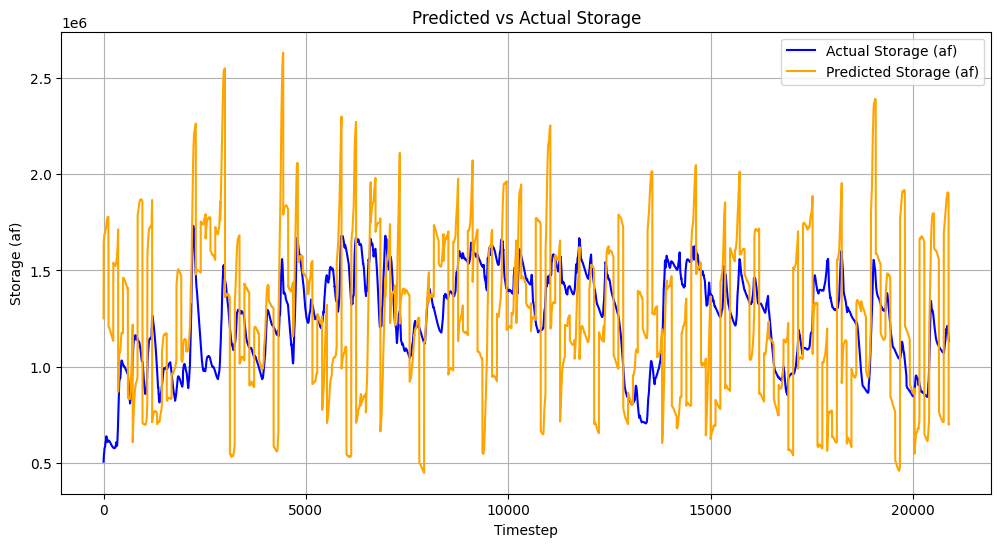

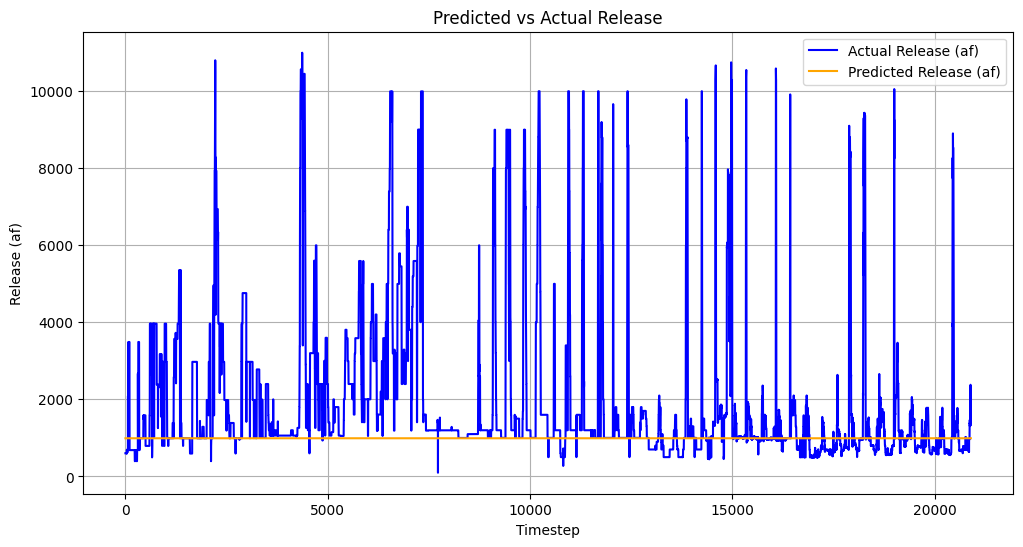

In [ ]:
# Load the trained PPO agent
from stable_baselines3 import TD3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load trained PPO model
model = TD3.load("td3_reservoir_agent")

# Set up variables for predictions
predicted_storage = []
actual_storage = []
predicted_release = []
actual_release = []

# Initialize current storage
current_storage = dataset[0, 0]  # First storage value from dataset
print(f"Initial Storage: {current_storage} AF")

# Perform predictions for the entire dataset
for i in range(len(dataset)):
    # Get the observation
    observation = np.array([current_storage, dataset[i, 1], dataset[i, 2]], dtype=np.float32)

    # Predict action
    action, _ = model.predict(observation)
    normalized_release = np.clip((action[0] + 1) / 2, 0, 1)

    # Map normalized action to release value in acre-feet
    predicted_release_af = min_release_af + normalized_release * (max_release_af - min_release_af)

    # Extract actual inflow and evaporation from dataset
    inflow_af = dataset[i, 2]
    evaporation_af = dataset[i, 1]

    # Update the current storage using the predicted release, inflow, and evaporation
    current_storage = current_storage + inflow_af - evaporation_af - predicted_release_af

    # Store results for analysis
    predicted_storage.append(current_storage)
    predicted_release.append(predicted_release_af)
    actual_storage.append(dataset[i, 0])  # Actual storage from the dataset
    actual_release.append(dataset[i, 3])  # Actual release from the dataset

# Save results to CSV files
predicted_vs_actual_storage = pd.DataFrame({
    "Predicted Storage (af)": predicted_storage,
    "Actual Storage (af)": actual_storage
})
predicted_vs_actual_release = pd.DataFrame({
    "Predicted Release (af)": predicted_release,
    "Actual Release (af)": actual_release
})

predicted_vs_actual_storage.to_csv("predicted_vs_actual_storage_complete_data.csv", index=False)
predicted_vs_actual_release.to_csv("predicted_vs_actual_release_complete_data.csv", index=False)

print("Prediction completed and saved.")

# Plot Predicted vs Actual Storage
plt.figure(figsize=(12, 6))
plt.plot(actual_storage, label="Actual Storage (af)", color="blue")
plt.plot(predicted_storage, label="Predicted Storage (af)", color="orange")
plt.xlabel("Timestep")
plt.ylabel("Storage (af)")
plt.title("Predicted vs Actual Storage")
plt.legend()
plt.grid()
plt.show()

# Plot Predicted vs Actual Release
plt.figure(figsize=(12, 6))
plt.plot(actual_release, label="Actual Release (af)", color="blue")
plt.plot(predicted_release, label="Predicted Release (af)", color="orange")
plt.xlabel("Timestep")
plt.ylabel("Release (af)")
plt.title("Predicted vs Actual Release")
plt.legend()
plt.grid()
plt.show()

# **PPO agent with simple binary rewards for storage volume constraints with smaller time steps (threshold) each episode - Agent Based State Propagation**

In [ ]:
# Import necessary libraries
import os
import numpy as np
import pandas as pd
import torch as th
import gymnasium
from gymnasium import Env
from gymnasium.spaces import Box
from stable_baselines3 import PPO
import matplotlib.pyplot as plt

# Define storage and release limits
min_storage_af = 500000
max_storage_af = 1800000
initial_storage_af = 500000
target_storage_af = (min_storage_af + max_storage_af) / 2
min_release_af = 500 * 1.98211  # Minimum release in acre-feet
max_release_af = 4000 * 1.98211  # Maximum release in acre-feet

# Load and preprocess data
data = pd.read_csv('/content/Clipped_NAVAJORESERVOIR08-18-2024T16.48.23.csv')
storage = data['Storage (af)'].values
evaporation = data['Evaporation (af)'].values
inflow_cfs = data['Inflow** (cfs)'].values
release_cfs = data['Total Release (cfs)'].values
dataset = np.column_stack((storage, evaporation, inflow_cfs * 1.98211, release_cfs * 1.98211))

# Define the custom Reservoir environment for PPO
class ReservoirEnv(Env):
    def __init__(self, dataset, min_storage_af, max_storage_af, target_storage_af, min_release_af, max_release_af, episode_length):
        super(ReservoirEnv, self).__init__()
        self.data = dataset
        self.episode_length = episode_length
        self.min_storage_af = min_storage_af
        self.max_storage_af = max_storage_af
        self.target_storage_af = target_storage_af
        self.min_release_af = min_release_af
        self.max_release_af = max_release_af
        self.current_step = 0
        self.episode_step_count = 0
        self.reward_history = []
        self.episode_reward = []
        self.storage_history = []
        self.mean_storage_history = []
        self.release_history = []
        self.mean_release_history = []

        # Define action space (now scaled between 0 and 1)
        self.action_space = Box(low=0, high=1, shape=(1,), dtype=np.float32)

        # Define observation space
        self.observation_space = Box(
            low=np.array([self.min_storage_af, np.min(self.data[:, 1]), np.min(self.data[:, 2])]),
            high=np.array([self.max_storage_af, np.max(self.data[:, 1]), np.max(self.data[:, 2])]),
            dtype=np.float32
        )

    def reset(self, seed=None):
        self.current_step = np.random.randint(0, len(self.data) - self.episode_length)
        self.episode_step_count = 0
        self.reward_history.clear()
        self.storage_history.clear()
        self.release_history.clear()
        self.current_storage = self.data[self.current_step, 0]
        return self._get_observation(), {}

    def _get_observation(self):
        return np.array([self.current_storage, self.data[self.current_step, 1], self.data[self.current_step, 2]])

    def step(self, action):
        # Convert action from [0,1] to actual release range
        release_af_value = self.min_release_af + action[0] * (self.max_release_af - self.min_release_af)

        # Get inflow and evaporation
        inflow_af = self.data[self.current_step, 2]
        evaporation_af = self.data[self.current_step, 1]

        # Update storage
        self.current_storage = self.current_storage + inflow_af - evaporation_af - release_af_value

        # Reward
        if self.min_storage_af <= self.current_storage <= self.max_storage_af:
            reward = 1
        else:
            reward = -1

        # Store histories
        self.reward_history.append(reward)
        self.storage_history.append(self.current_storage)
        self.release_history.append(release_af_value)

        self.current_step += 1
        self.episode_step_count += 1
        done = self.current_step >= len(self.data) or (self.episode_step_count >= self.episode_length)

        if done:
            cum_reward = sum(self.reward_history)
            self.episode_reward.append(cum_reward)
            self.mean_storage_history.append(np.mean(self.storage_history))
            self.mean_release_history.append(np.mean(self.release_history))

        observation = self._get_observation() if not done else np.zeros(3)
        return observation, reward, done, False, {}

# Set up environment
episode_length = 60
env = ReservoirEnv(dataset, min_storage_af, max_storage_af, target_storage_af, min_release_af, max_release_af, episode_length)

# Initialize PPO model
model = PPO("MlpPolicy", env, verbose=1)

# Train the model
n_episodes = 5000
total_timesteps = n_episodes * episode_length
model.learn(total_timesteps=total_timesteps)

# Save model
model.save("ppo_reservoir_agent")

# Save cumulative reward values to CSV
pd.DataFrame(env.episode_reward, columns=["Cumulative Reward"]).to_csv("cumulative_reward_per_episode.csv", index=False)

# Plot cumulative rewards per episode
plt.figure(figsize=(12, 6))
plt.plot(env.episode_reward, label="Cumulative Reward per Episode", color="blue")
plt.xlabel("Episode")
plt.ylabel("Cumulative Reward")
plt.title("Cumulative Reward per Episode vs Episode Number")
plt.grid()
plt.legend()
plt.savefig("cumulative_rewards_per_episode.png")
plt.show()

# Plot mean storage per episode
plt.figure(figsize=(12, 6))
plt.plot(env.mean_storage_history, label="Mean Storage per Episode", color="blue")
plt.xlabel("Episode")
plt.ylabel("Mean Storage")
plt.title("Mean Storage per Episode vs Episode Number")
plt.grid()
plt.legend()
plt.savefig("mean_storage_per_episode.png")
plt.show()

# Plot mean release per episode
plt.figure(figsize=(12, 6))
plt.plot(env.mean_release_history, label="Mean Release per Episode", color="blue")
plt.xlabel("Episode")
plt.ylabel("Mean Release")
plt.title("Mean Release per Episode vs Episode Number")
plt.grid()
plt.legend()
plt.savefig("mean_release_per_episode.png")
plt.show()

print("Training complete. Model and reward plots saved.")

In [ ]:
# Load the trained PPO agent
from stable_baselines3 import PPO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load trained PPO model
model = PPO.load("ppo_reservoir_agent")

# Set up variables for predictions
predicted_storage = []
actual_storage = []
predicted_release = []
actual_release = []

# Initialize current storage
current_storage = dataset[0, 0]  # First storage value from dataset
print(f"Initial Storage: {current_storage} AF")

# Perform predictions for the entire dataset
for i in range(len(dataset)):
    # Get the observation
    observation = np.array([current_storage, dataset[i, 1], dataset[i, 2]], dtype=np.float32)

    # Predict action
    action, _ = model.predict(observation)

    # Map normalized action to release value in acre-feet
    predicted_release_af = min_release_af + action[0] * (max_release_af - min_release_af)

    # Extract actual inflow and evaporation from dataset
    inflow_af = dataset[i, 2]
    evaporation_af = dataset[i, 1]

    # Update the current storage using the predicted release, inflow, and evaporation
    current_storage = current_storage + inflow_af - evaporation_af - predicted_release_af

    # Store results for analysis
    predicted_storage.append(current_storage)
    predicted_release.append(predicted_release_af)
    actual_storage.append(dataset[i, 0])  # Actual storage from the dataset
    actual_release.append(dataset[i, 3])  # Actual release from the dataset

# Save results to CSV files
predicted_vs_actual_storage = pd.DataFrame({
    "Predicted Storage (af)": predicted_storage,
    "Actual Storage (af)": actual_storage
})
predicted_vs_actual_release = pd.DataFrame({
    "Predicted Release (af)": predicted_release,
    "Actual Release (af)": actual_release
})

predicted_vs_actual_storage.to_csv("predicted_vs_actual_storage_complete_data.csv", index=False)
predicted_vs_actual_release.to_csv("predicted_vs_actual_release_complete_data.csv", index=False)

print("Prediction completed and saved.")

# Plot Predicted vs Actual Storage
plt.figure(figsize=(12, 6))
plt.plot(actual_storage, label="Actual Storage (af)", color="blue")
plt.plot(predicted_storage, label="Predicted Storage (af)", color="orange")
plt.xlabel("Timestep")
plt.ylabel("Storage (af)")
plt.title("Predicted vs Actual Storage")
plt.legend()
plt.grid()
plt.show()

# Plot Predicted vs Actual Release
plt.figure(figsize=(12, 6))
plt.plot(actual_release, label="Actual Release (af)", color="blue")
plt.plot(predicted_release, label="Predicted Release (af)", color="orange")
plt.xlabel("Timestep")
plt.ylabel("Release (af)")
plt.title("Predicted vs Actual Release")
plt.legend()
plt.grid()
plt.show()

/usr/local/lib/python3.11/dist-packages/gymnasium/spaces/box.py:235: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/usr/local/lib/python3.11/dist-packages/gymnasium/spaces/box.py:305: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


Streaming output truncated to the last 5000 lines.
|    n_updates       | 440059   |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 120      |
|    ep_rew_mean     | 115      |
| time/              |          |
|    episodes        | 3672     |
|    fps             | 26       |
|    time_elapsed    | 4        |
|    total_timesteps | 440640   |
| train/             |          |
|    actor_loss      | -47.3    |
|    critic_loss     | 52.6     |
|    learning_rate   | 0.001    |
|    n_updates       | 440539   |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 120      |
|    ep_rew_mean     | 114      |
| time/              |          |
|    episodes        | 3676     |
|    fps             | 22       |
|    time_elapsed    | 5        |
|    total_timesteps | 441120   |
| train/             |          |
|    actor_loss      | -47.3   

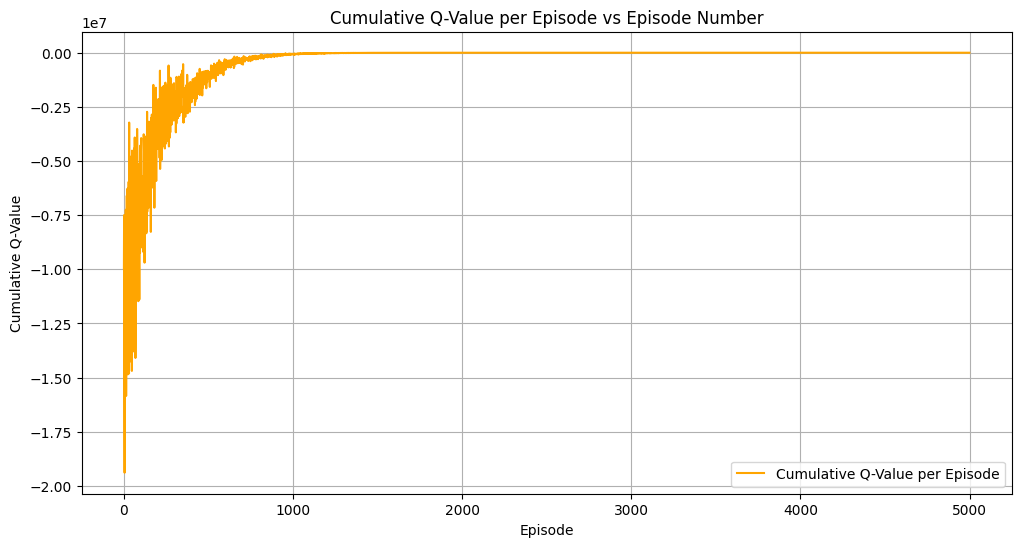

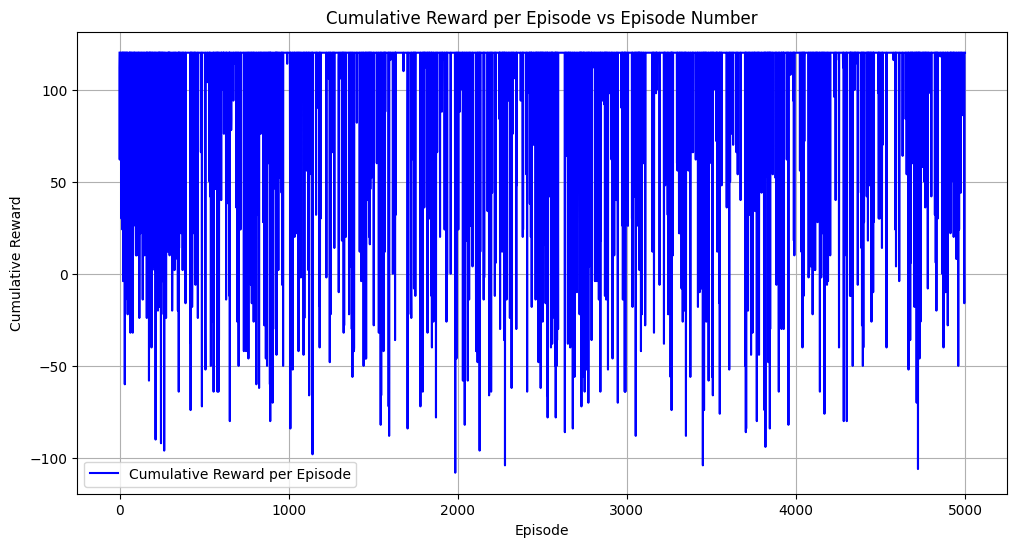

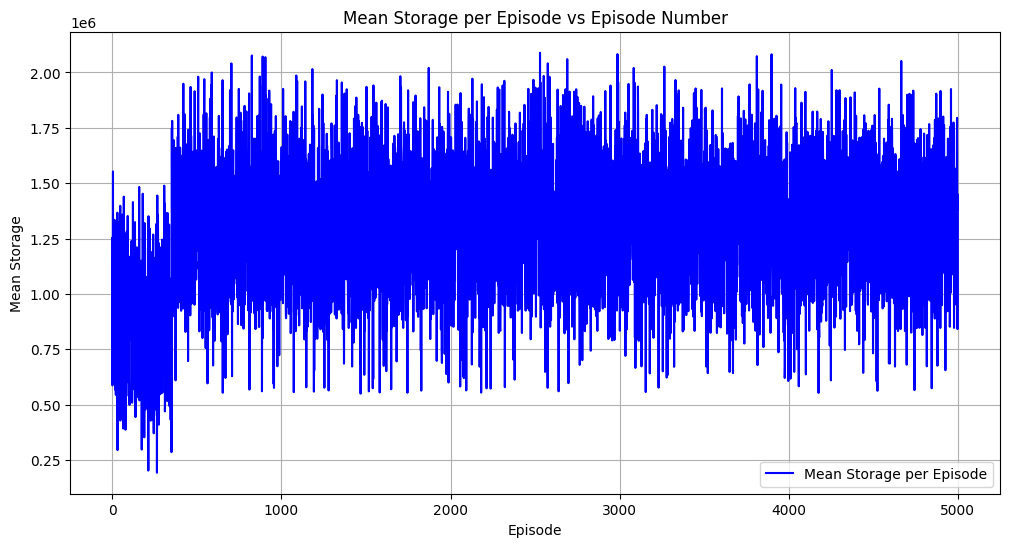

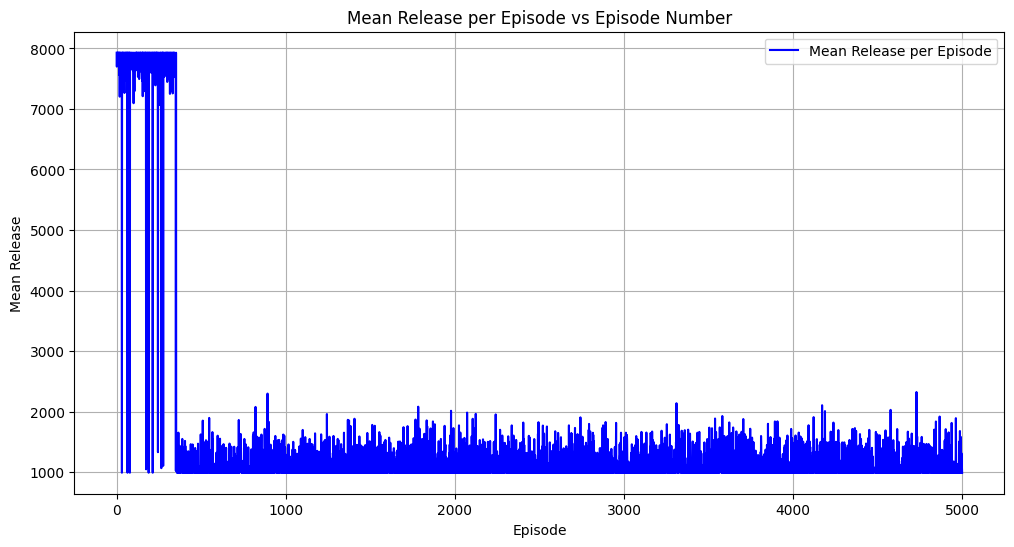

Training complete. Model checkpoints, Q values, and reward plots saved.


In [2]:
# Import necessary libraries
import os
import numpy as np
import pandas as pd
import torch as th
import gymnasium
from gymnasium import Env
from gymnasium.spaces import Box
from stable_baselines3 import TD3
from stable_baselines3.common.noise import NormalActionNoise
import matplotlib.pyplot as plt

# Define storage and release limits
min_storage_af = 500000
max_storage_af = 1800000
initial_storage_af = 500000
target_storage_af = (min_storage_af + max_storage_af) / 2
min_release_af = 500 * 1.98211  # Minimum release in acre-feet
max_release_af = 4000 * 1.98211  # Maximum release in acre-feet

# Load and preprocess data
data = pd.read_csv('/content/Clipped_NAVAJORESERVOIR08-18-2024T16.48.23.csv')
storage = data['Storage (af)'].values
evaporation = data['Evaporation (af)'].values
inflow_cfs = data['Inflow** (cfs)'].values
release_cfs = data['Total Release (cfs)'].values
dataset = np.column_stack((storage, evaporation, inflow_cfs * 1.98211, release_cfs * 1.98211))

# Define the custom Reservoir environment
class ReservoirEnv(Env):
    def __init__(self, dataset, min_storage_af, max_storage_af, min_release_af, max_release_af, episode_length, td3_model):
        super(ReservoirEnv, self).__init__()
        self.data = dataset
        self.episode_length = episode_length
        self.min_storage_af = min_storage_af
        self.max_storage_af = max_storage_af
        self.min_release_af = min_release_af
        self.max_release_af = max_release_af
        self.td3_model = td3_model  # To compute Q-values
        self.current_step = 0
        self.episode_step_count = 0
        self.reward_history = []
        self.episode_reward = []
        self.storage_history = []
        self.mean_storage_history = []
        self.q_values = []  # To collect Q-values for each step
        self.cumulative_q_values = []  # To store cumulative Q-values per episode
        self.release_history = []
        self.mean_release_history = []

        # Define action space and observation space
        self.action_space = Box(low=-1, high=1, shape=(1,), dtype=np.float32)
        self.observation_space = Box(low=np.array([self.min_storage_af, np.min(self.data[:, 1]), np.min(self.data[:, 2])]),
                                     high=np.array([self.max_storage_af, np.max(self.data[:, 1]), np.max(self.data[:, 2])]),
                                     dtype=np.float32)

    def reset(self, seed=None):
        self.current_step = np.random.randint(0, len(self.data) - self.episode_length)
        self.episode_step_count = 0
        self.reward_history.clear()
        self.q_values.clear()  # Reset Q-value history
        self.storage_history.clear()
        self.release_history.clear()
        self.current_storage = self.data[self.current_step, 0]
        return self._get_observation(), {}

    def _get_observation(self):
        return np.array([self.current_storage, self.data[self.current_step, 1], self.data[self.current_step, 2]])

    def step(self, action):
        normalized_release = np.clip((action[0] + 1) / 2, 0, 1)
        release_af_value = self.min_release_af + normalized_release * (self.max_release_af - self.min_release_af)

        inflow_af = self.data[self.current_step, 2]
        evaporation_af = self.data[self.current_step, 1]
        self.current_storage += inflow_af - evaporation_af - release_af_value

         # Compute Rewards
        if self.min_storage_af <= self.current_storage <= self.max_storage_af:
            reward = 1
        else:
            reward = -1

        # Compute Q-value
        obs_tensor = th.tensor(self._get_observation(), dtype=th.float32).unsqueeze(0).to(self.td3_model.device)
        action_tensor = th.tensor(action, dtype=th.float32).unsqueeze(0).to(self.td3_model.device)
        with th.no_grad():
            q_value = self.td3_model.critic(obs_tensor, action_tensor)[0].mean().item()
        self.q_values.append(q_value)

        self.reward_history.append(reward)
        self.storage_history.append(self.current_storage)
        self.current_step += 1
        self.episode_step_count += 1
        done = self.current_step >= len(self.data) or (self.episode_step_count % self.episode_length == 0)

        if done:
            cum_reward = sum(self.reward_history)
            self.episode_reward.append(cum_reward)
            self.mean_storage_history.append(np.mean(self.storage_history))
            self.cumulative_q_values.append(np.sum(self.q_values))
            self.release_history.append(release_af_value)
            self.mean_release_history.append(np.mean(self.release_history))

        observation = self._get_observation() if not done else np.zeros(3)
        return observation, reward, done, False, {}

# Set up environment
episode_length = 120
env = ReservoirEnv(dataset, min_storage_af, max_storage_af, min_release_af, max_release_af, episode_length, None)

# Initialize TD3 model
n_actions = env.action_space.shape[-1]
action_noise = NormalActionNoise(mean=np.zeros(n_actions), sigma=0.1 * np.ones(n_actions))
model = TD3("MlpPolicy", env, action_noise=action_noise, verbose=1)
env.td3_model = model  # Pass the TD3 model to the environment

# Train the model with periodic saving
n_episodes = 5000
save_interval = 500  # Save every 500 episodes
total_timesteps = n_episodes * episode_length

for episode in range(1, n_episodes + 1):
    model.learn(total_timesteps=episode_length, reset_num_timesteps=False)

    # Save model every 500 episodes
    if episode % save_interval == 0:
        model_path = f"td3_reservoir_agent_ep_{episode}.zip"
        model.save(model_path)
        print(f"Model saved at episode {episode}")

# Save final model
model.save("td3_reservoir_agent_final")

# Save cumulative Q-values to CSV
pd.DataFrame(env.cumulative_q_values, columns=["Cumulative Q-Value"]).to_csv("cumulative_q_values_per_episode.csv", index=False)

# Save cumulative reward values to CSV
pd.DataFrame(env.episode_reward).to_csv("cumulative_reward_per_episode.csv", index=False)

# Plot cumulative Q-values per episode
plt.figure(figsize=(12, 6))
plt.plot(env.cumulative_q_values, label="Cumulative Q-Value per Episode", color="orange")
plt.xlabel("Episode")
plt.ylabel("Cumulative Q-Value")
plt.title("Cumulative Q-Value per Episode vs Episode Number")
plt.grid()
plt.legend()
plt.savefig("cumulative_q_values_per_episode.png")
plt.show()

# Plot cumulative rewards per episode
plt.figure(figsize=(12, 6))
plt.plot(env.episode_reward, label="Cumulative Reward per Episode", color="blue")
plt.xlabel("Episode")
plt.ylabel("Cumulative Reward")
plt.title("Cumulative Reward per Episode vs Episode Number")
plt.grid()
plt.legend()
plt.savefig("cumulative_rewards_per_episode.png")
plt.show()

# Plot mean storage per episode
plt.figure(figsize=(12, 6))
plt.plot(env.mean_storage_history, label="Mean Storage per Episode", color="blue")
plt.xlabel("Episode")
plt.ylabel("Mean Storage")
plt.title("Mean Storage per Episode vs Episode Number")
plt.grid()
plt.legend()
plt.savefig("mean_storage_per_episode.png")
plt.show()

# Plot mean release per episode
plt.figure(figsize=(12, 6))
plt.plot(env.mean_release_history, label="Mean Release per Episode", color="blue")
plt.xlabel("Episode")
plt.ylabel("Mean Release")
plt.title("Mean Release per Episode vs Episode Number")
plt.grid()
plt.legend()
plt.savefig("mean_release_per_episode.png")
plt.show()

print("Training complete. Model checkpoints, Q values, and reward plots saved.")

Initial Storage: 506159.0 AF
Prediction completed and saved.


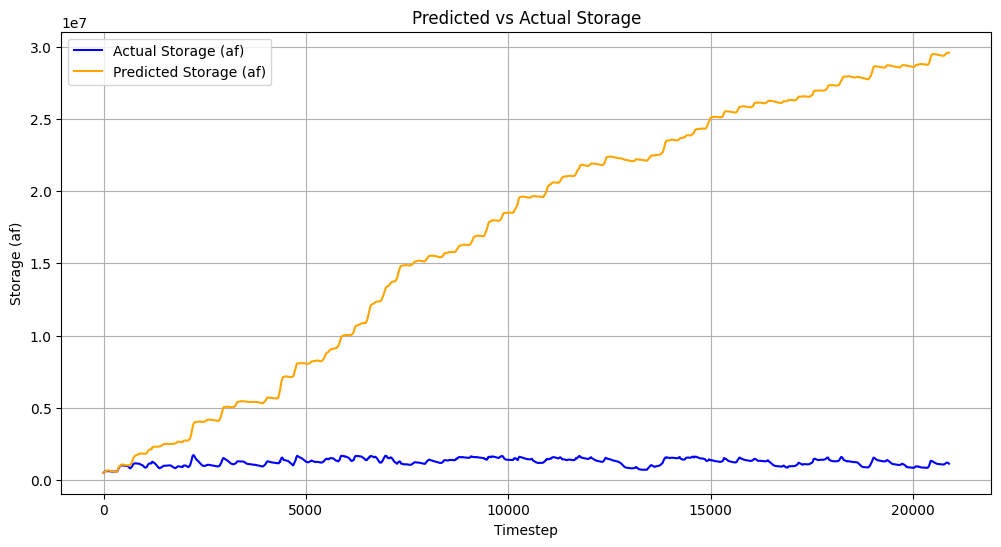

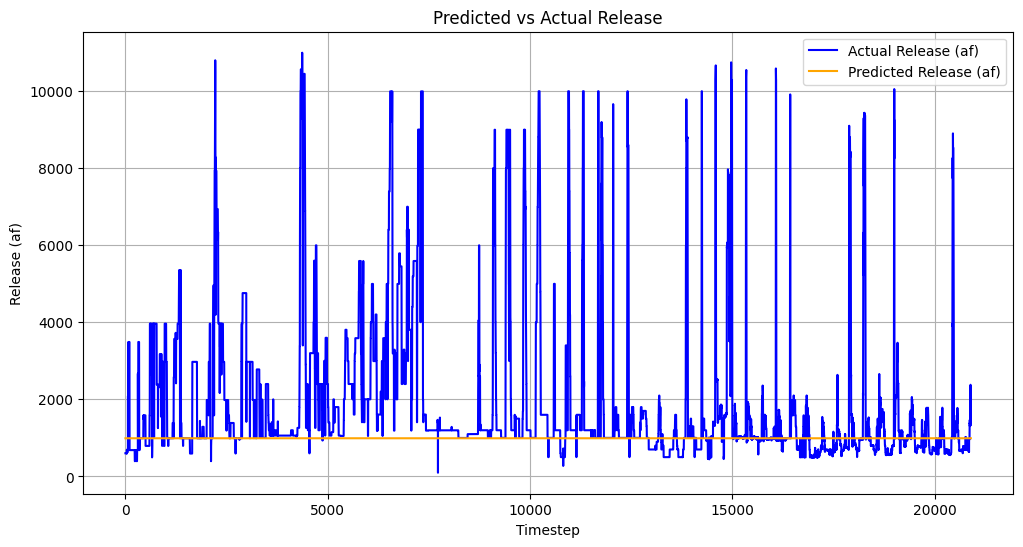

In [4]:
# Load the trained PPO agent
from stable_baselines3 import TD3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load trained PPO model
model = TD3.load("td3_reservoir_agent_ep_5000")

# Set up variables for predictions
predicted_storage = []
actual_storage = []
predicted_release = []
actual_release = []

# Initialize current storage
current_storage = dataset[0, 0]  # First storage value from dataset
print(f"Initial Storage: {current_storage} AF")

# Perform predictions for the entire dataset
for i in range(len(dataset)):
    # Get the observation
    observation = np.array([current_storage, dataset[i, 1], dataset[i, 2]], dtype=np.float32)

    # Predict action
    action, _ = model.predict(observation)
    normalized_release = np.clip((action[0] + 1) / 2, 0, 1)

    # Map normalized action to release value in acre-feet
    predicted_release_af = min_release_af + normalized_release * (max_release_af - min_release_af)

    # Extract actual inflow and evaporation from dataset
    inflow_af = dataset[i, 2]
    evaporation_af = dataset[i, 1]

    # Update the current storage using the predicted release, inflow, and evaporation
    current_storage = current_storage + inflow_af - evaporation_af - predicted_release_af

    # Store results for analysis
    predicted_storage.append(current_storage)
    predicted_release.append(predicted_release_af)
    actual_storage.append(dataset[i, 0])  # Actual storage from the dataset
    actual_release.append(dataset[i, 3])  # Actual release from the dataset

# Save results to CSV files
predicted_vs_actual_storage = pd.DataFrame({
    "Predicted Storage (af)": predicted_storage,
    "Actual Storage (af)": actual_storage
})
predicted_vs_actual_release = pd.DataFrame({
    "Predicted Release (af)": predicted_release,
    "Actual Release (af)": actual_release
})

predicted_vs_actual_storage.to_csv("predicted_vs_actual_storage_complete_data.csv", index=False)
predicted_vs_actual_release.to_csv("predicted_vs_actual_release_complete_data.csv", index=False)

print("Prediction completed and saved.")

# Plot Predicted vs Actual Storage
plt.figure(figsize=(12, 6))
plt.plot(actual_storage, label="Actual Storage (af)", color="blue")
plt.plot(predicted_storage, label="Predicted Storage (af)", color="orange")
plt.xlabel("Timestep")
plt.ylabel("Storage (af)")
plt.title("Predicted vs Actual Storage")
plt.legend()
plt.grid()
plt.show()

# Plot Predicted vs Actual Release
plt.figure(figsize=(12, 6))
plt.plot(actual_release, label="Actual Release (af)", color="blue")
plt.plot(predicted_release, label="Predicted Release (af)", color="orange")
plt.xlabel("Timestep")
plt.ylabel("Release (af)")
plt.title("Predicted vs Actual Release")
plt.legend()
plt.grid()
plt.show()

Initial Storage: 506159.0 AF
Prediction completed and saved.


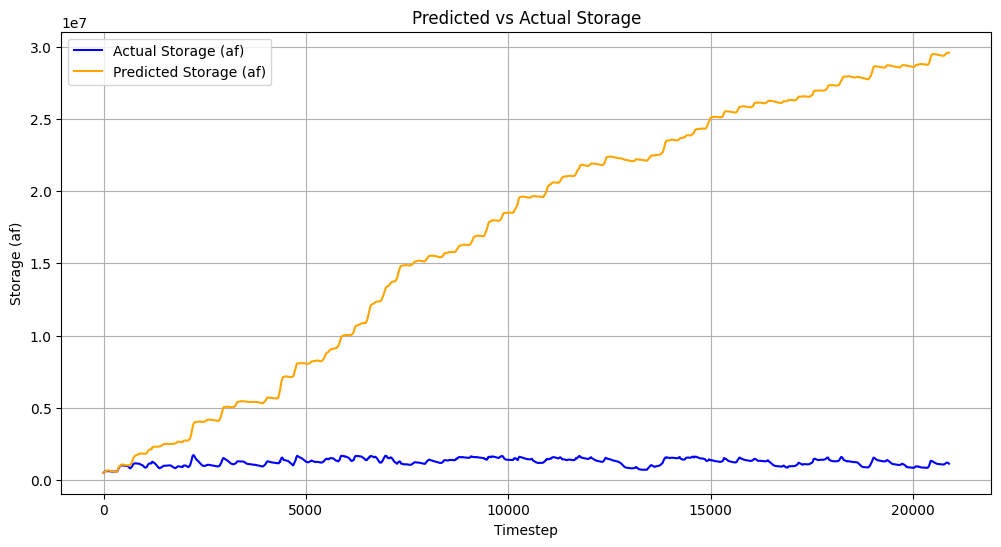

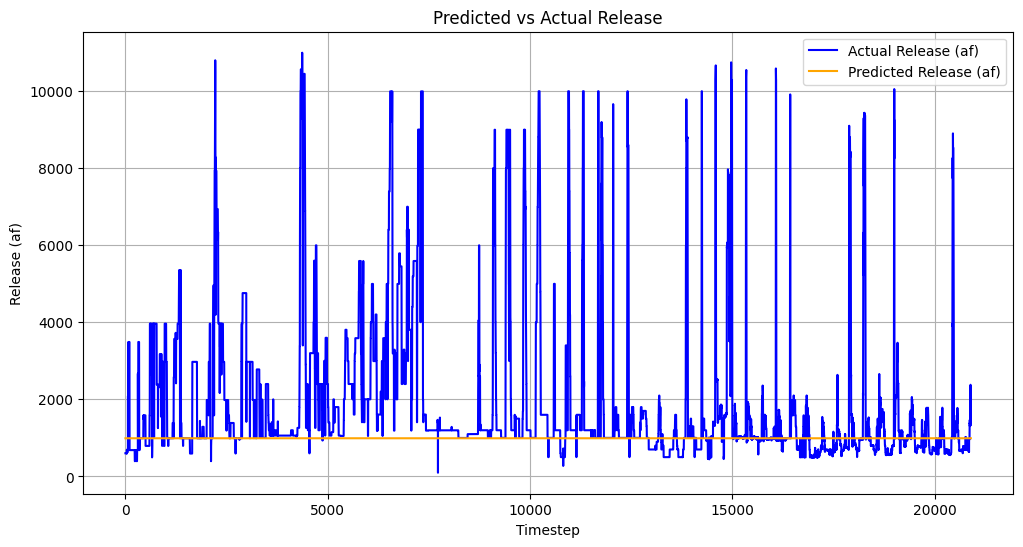

In [5]:
# Load the trained PPO agent
from stable_baselines3 import TD3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load trained PPO model
model = TD3.load("td3_reservoir_agent_ep_4500")

# Set up variables for predictions
predicted_storage = []
actual_storage = []
predicted_release = []
actual_release = []

# Initialize current storage
current_storage = dataset[0, 0]  # First storage value from dataset
print(f"Initial Storage: {current_storage} AF")

# Perform predictions for the entire dataset
for i in range(len(dataset)):
    # Get the observation
    observation = np.array([current_storage, dataset[i, 1], dataset[i, 2]], dtype=np.float32)

    # Predict action
    action, _ = model.predict(observation)
    normalized_release = np.clip((action[0] + 1) / 2, 0, 1)

    # Map normalized action to release value in acre-feet
    predicted_release_af = min_release_af + normalized_release * (max_release_af - min_release_af)

    # Extract actual inflow and evaporation from dataset
    inflow_af = dataset[i, 2]
    evaporation_af = dataset[i, 1]

    # Update the current storage using the predicted release, inflow, and evaporation
    current_storage = current_storage + inflow_af - evaporation_af - predicted_release_af

    # Store results for analysis
    predicted_storage.append(current_storage)
    predicted_release.append(predicted_release_af)
    actual_storage.append(dataset[i, 0])  # Actual storage from the dataset
    actual_release.append(dataset[i, 3])  # Actual release from the dataset

# Save results to CSV files
predicted_vs_actual_storage = pd.DataFrame({
    "Predicted Storage (af)": predicted_storage,
    "Actual Storage (af)": actual_storage
})
predicted_vs_actual_release = pd.DataFrame({
    "Predicted Release (af)": predicted_release,
    "Actual Release (af)": actual_release
})

predicted_vs_actual_storage.to_csv("predicted_vs_actual_storage_complete_data.csv", index=False)
predicted_vs_actual_release.to_csv("predicted_vs_actual_release_complete_data.csv", index=False)

print("Prediction completed and saved.")

# Plot Predicted vs Actual Storage
plt.figure(figsize=(12, 6))
plt.plot(actual_storage, label="Actual Storage (af)", color="blue")
plt.plot(predicted_storage, label="Predicted Storage (af)", color="orange")
plt.xlabel("Timestep")
plt.ylabel("Storage (af)")
plt.title("Predicted vs Actual Storage")
plt.legend()
plt.grid()
plt.show()

# Plot Predicted vs Actual Release
plt.figure(figsize=(12, 6))
plt.plot(actual_release, label="Actual Release (af)", color="blue")
plt.plot(predicted_release, label="Predicted Release (af)", color="orange")
plt.xlabel("Timestep")
plt.ylabel("Release (af)")
plt.title("Predicted vs Actual Release")
plt.legend()
plt.grid()
plt.show()

Initial Storage: 506159.0 AF
Prediction completed and saved.


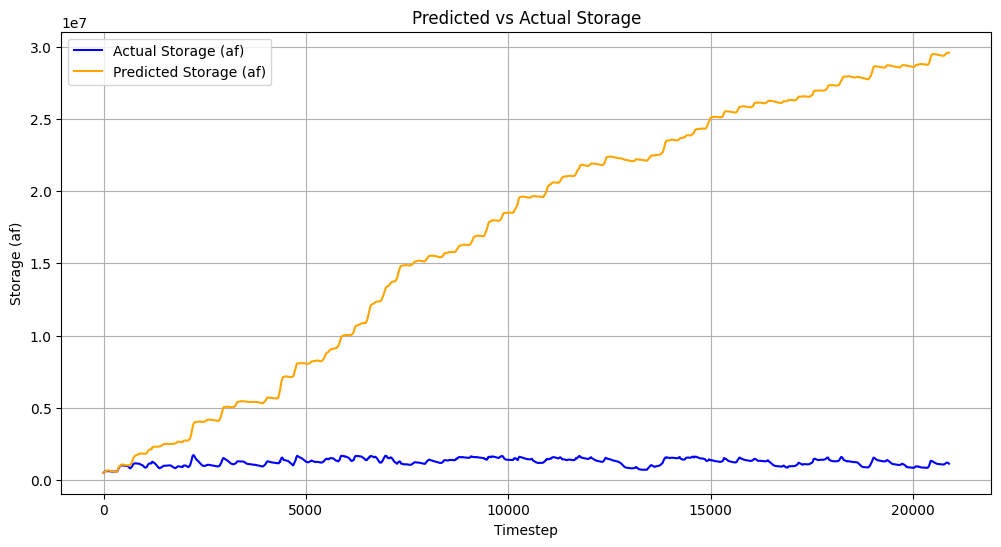

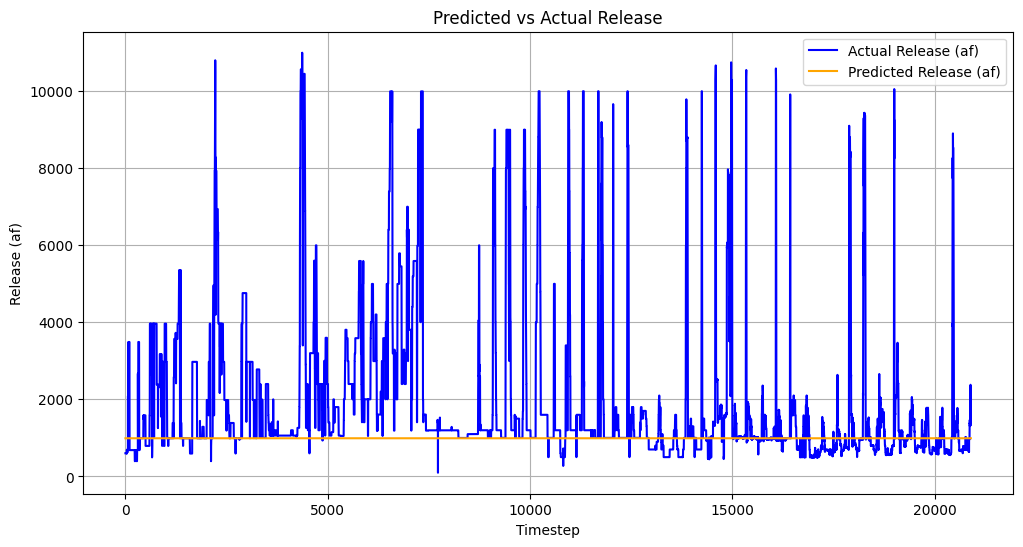

In [6]:
# Load the trained PPO agent
from stable_baselines3 import TD3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load trained PPO model
model = TD3.load("td3_reservoir_agent_ep_3000")

# Set up variables for predictions
predicted_storage = []
actual_storage = []
predicted_release = []
actual_release = []

# Initialize current storage
current_storage = dataset[0, 0]  # First storage value from dataset
print(f"Initial Storage: {current_storage} AF")

# Perform predictions for the entire dataset
for i in range(len(dataset)):
    # Get the observation
    observation = np.array([current_storage, dataset[i, 1], dataset[i, 2]], dtype=np.float32)

    # Predict action
    action, _ = model.predict(observation)
    normalized_release = np.clip((action[0] + 1) / 2, 0, 1)

    # Map normalized action to release value in acre-feet
    predicted_release_af = min_release_af + normalized_release * (max_release_af - min_release_af)

    # Extract actual inflow and evaporation from dataset
    inflow_af = dataset[i, 2]
    evaporation_af = dataset[i, 1]

    # Update the current storage using the predicted release, inflow, and evaporation
    current_storage = current_storage + inflow_af - evaporation_af - predicted_release_af

    # Store results for analysis
    predicted_storage.append(current_storage)
    predicted_release.append(predicted_release_af)
    actual_storage.append(dataset[i, 0])  # Actual storage from the dataset
    actual_release.append(dataset[i, 3])  # Actual release from the dataset

# Save results to CSV files
predicted_vs_actual_storage = pd.DataFrame({
    "Predicted Storage (af)": predicted_storage,
    "Actual Storage (af)": actual_storage
})
predicted_vs_actual_release = pd.DataFrame({
    "Predicted Release (af)": predicted_release,
    "Actual Release (af)": actual_release
})

predicted_vs_actual_storage.to_csv("predicted_vs_actual_storage_complete_data.csv", index=False)
predicted_vs_actual_release.to_csv("predicted_vs_actual_release_complete_data.csv", index=False)

print("Prediction completed and saved.")

# Plot Predicted vs Actual Storage
plt.figure(figsize=(12, 6))
plt.plot(actual_storage, label="Actual Storage (af)", color="blue")
plt.plot(predicted_storage, label="Predicted Storage (af)", color="orange")
plt.xlabel("Timestep")
plt.ylabel("Storage (af)")
plt.title("Predicted vs Actual Storage")
plt.legend()
plt.grid()
plt.show()

# Plot Predicted vs Actual Release
plt.figure(figsize=(12, 6))
plt.plot(actual_release, label="Actual Release (af)", color="blue")
plt.plot(predicted_release, label="Predicted Release (af)", color="orange")
plt.xlabel("Timestep")
plt.ylabel("Release (af)")
plt.title("Predicted vs Actual Release")
plt.legend()
plt.grid()
plt.show()

Initial Storage: 506159.0 AF
Prediction completed and saved.


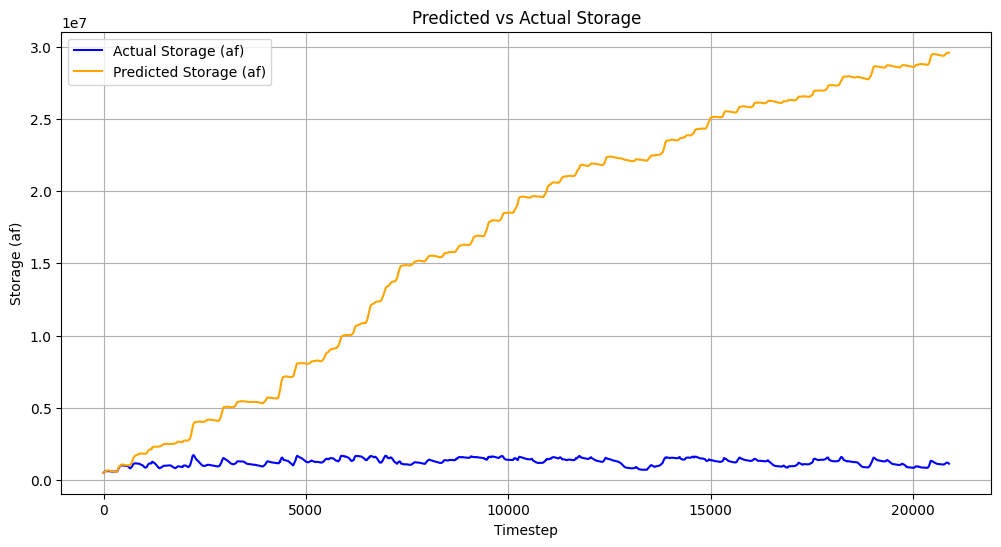

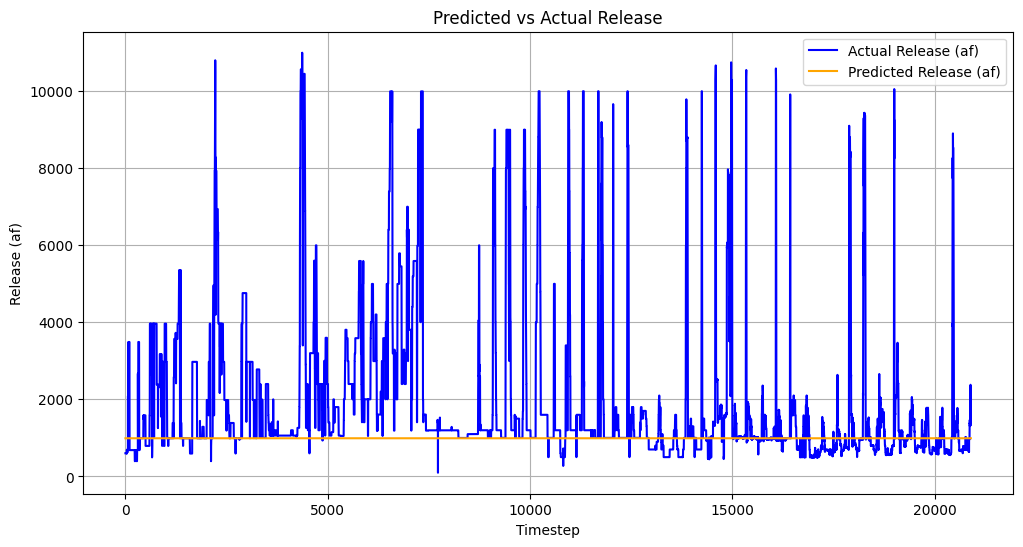

In [7]:
# Load the trained PPO agent
from stable_baselines3 import TD3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load trained PPO model
model = TD3.load("td3_reservoir_agent_ep_2000")

# Set up variables for predictions
predicted_storage = []
actual_storage = []
predicted_release = []
actual_release = []

# Initialize current storage
current_storage = dataset[0, 0]  # First storage value from dataset
print(f"Initial Storage: {current_storage} AF")

# Perform predictions for the entire dataset
for i in range(len(dataset)):
    # Get the observation
    observation = np.array([current_storage, dataset[i, 1], dataset[i, 2]], dtype=np.float32)

    # Predict action
    action, _ = model.predict(observation)
    normalized_release = np.clip((action[0] + 1) / 2, 0, 1)

    # Map normalized action to release value in acre-feet
    predicted_release_af = min_release_af + normalized_release * (max_release_af - min_release_af)

    # Extract actual inflow and evaporation from dataset
    inflow_af = dataset[i, 2]
    evaporation_af = dataset[i, 1]

    # Update the current storage using the predicted release, inflow, and evaporation
    current_storage = current_storage + inflow_af - evaporation_af - predicted_release_af

    # Store results for analysis
    predicted_storage.append(current_storage)
    predicted_release.append(predicted_release_af)
    actual_storage.append(dataset[i, 0])  # Actual storage from the dataset
    actual_release.append(dataset[i, 3])  # Actual release from the dataset

# Save results to CSV files
predicted_vs_actual_storage = pd.DataFrame({
    "Predicted Storage (af)": predicted_storage,
    "Actual Storage (af)": actual_storage
})
predicted_vs_actual_release = pd.DataFrame({
    "Predicted Release (af)": predicted_release,
    "Actual Release (af)": actual_release
})

predicted_vs_actual_storage.to_csv("predicted_vs_actual_storage_complete_data.csv", index=False)
predicted_vs_actual_release.to_csv("predicted_vs_actual_release_complete_data.csv", index=False)

print("Prediction completed and saved.")

# Plot Predicted vs Actual Storage
plt.figure(figsize=(12, 6))
plt.plot(actual_storage, label="Actual Storage (af)", color="blue")
plt.plot(predicted_storage, label="Predicted Storage (af)", color="orange")
plt.xlabel("Timestep")
plt.ylabel("Storage (af)")
plt.title("Predicted vs Actual Storage")
plt.legend()
plt.grid()
plt.show()

# Plot Predicted vs Actual Release
plt.figure(figsize=(12, 6))
plt.plot(actual_release, label="Actual Release (af)", color="blue")
plt.plot(predicted_release, label="Predicted Release (af)", color="orange")
plt.xlabel("Timestep")
plt.ylabel("Release (af)")
plt.title("Predicted vs Actual Release")
plt.legend()
plt.grid()
plt.show()

Initial Storage: 506159.0 AF
Prediction completed and saved.


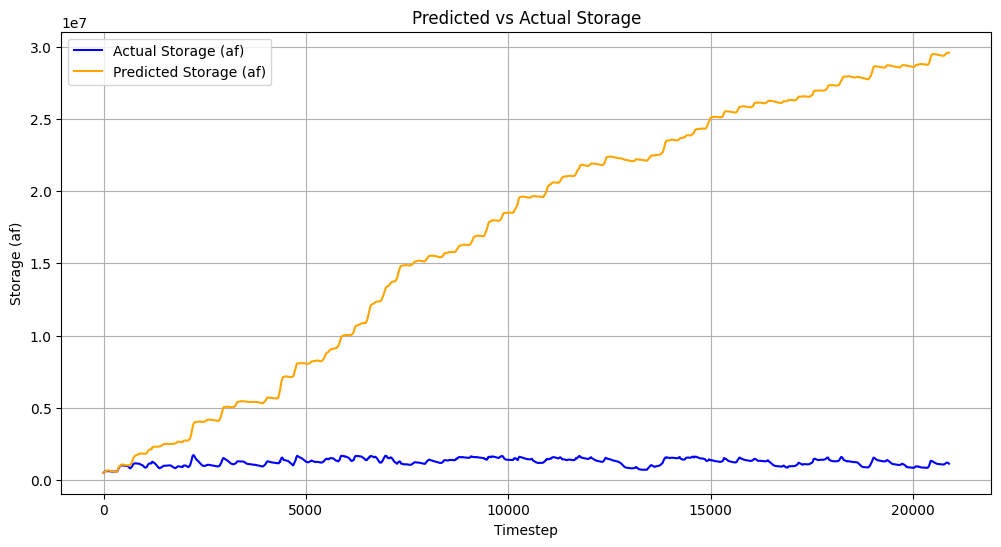

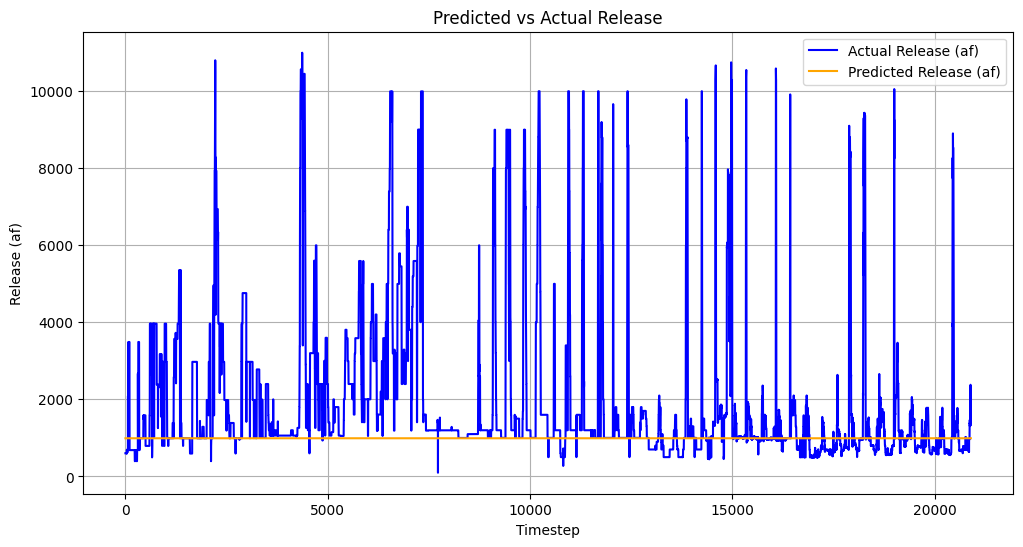

In [8]:
# Load the trained PPO agent
from stable_baselines3 import TD3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load trained PPO model
model = TD3.load("td3_reservoir_agent_ep_500")

# Set up variables for predictions
predicted_storage = []
actual_storage = []
predicted_release = []
actual_release = []

# Initialize current storage
current_storage = dataset[0, 0]  # First storage value from dataset
print(f"Initial Storage: {current_storage} AF")

# Perform predictions for the entire dataset
for i in range(len(dataset)):
    # Get the observation
    observation = np.array([current_storage, dataset[i, 1], dataset[i, 2]], dtype=np.float32)

    # Predict action
    action, _ = model.predict(observation)
    normalized_release = np.clip((action[0] + 1) / 2, 0, 1)

    # Map normalized action to release value in acre-feet
    predicted_release_af = min_release_af + normalized_release * (max_release_af - min_release_af)

    # Extract actual inflow and evaporation from dataset
    inflow_af = dataset[i, 2]
    evaporation_af = dataset[i, 1]

    # Update the current storage using the predicted release, inflow, and evaporation
    current_storage = current_storage + inflow_af - evaporation_af - predicted_release_af

    # Store results for analysis
    predicted_storage.append(current_storage)
    predicted_release.append(predicted_release_af)
    actual_storage.append(dataset[i, 0])  # Actual storage from the dataset
    actual_release.append(dataset[i, 3])  # Actual release from the dataset

# Save results to CSV files
predicted_vs_actual_storage = pd.DataFrame({
    "Predicted Storage (af)": predicted_storage,
    "Actual Storage (af)": actual_storage
})
predicted_vs_actual_release = pd.DataFrame({
    "Predicted Release (af)": predicted_release,
    "Actual Release (af)": actual_release
})

predicted_vs_actual_storage.to_csv("predicted_vs_actual_storage_complete_data.csv", index=False)
predicted_vs_actual_release.to_csv("predicted_vs_actual_release_complete_data.csv", index=False)

print("Prediction completed and saved.")

# Plot Predicted vs Actual Storage
plt.figure(figsize=(12, 6))
plt.plot(actual_storage, label="Actual Storage (af)", color="blue")
plt.plot(predicted_storage, label="Predicted Storage (af)", color="orange")
plt.xlabel("Timestep")
plt.ylabel("Storage (af)")
plt.title("Predicted vs Actual Storage")
plt.legend()
plt.grid()
plt.show()

# Plot Predicted vs Actual Release
plt.figure(figsize=(12, 6))
plt.plot(actual_release, label="Actual Release (af)", color="blue")
plt.plot(predicted_release, label="Predicted Release (af)", color="orange")
plt.xlabel("Timestep")
plt.ylabel("Release (af)")
plt.title("Predicted vs Actual Release")
plt.legend()
plt.grid()
plt.show()